In [10]:
import pandas as pd
from bsse_calculator.plotting_helpers import (
    make_bsse_contour_plots,
    fit_gaussian,
    make_contour_plots_of_fitted_gaussian,
    predicted_v_actual_plot,
    make_error_contour_plots,
)

In [11]:
bsse_data_nwchem_kcal = pd.read_csv("BSSE_by_Ne_Ne_distance_nwchem.csv")

In [12]:
for column in bsse_data_nwchem_kcal.columns:
    if "energy" in column:
        bsse_data_nwchem_kcal[column] = bsse_data_nwchem_kcal[column].apply(
            lambda x: float(x.strip("()").split(",")[0])
        )
        bsse_data_nwchem_kcal[column] = bsse_data_nwchem_kcal[column].apply(
            lambda x: x * 627.5096
        )

In [13]:
total_energies = pd.DataFrame()

In [14]:
for column in bsse_data_nwchem_kcal.columns:
    if "Total_energy" in column:
        total_energies[column.replace("Total_energy_", "")] = bsse_data_nwchem_kcal[
            column
        ]

total_energies["x"] = bsse_data_nwchem_kcal["x"]
total_energies["y"] = bsse_data_nwchem_kcal["y"]
total_energies["z"] = bsse_data_nwchem_kcal["z"]

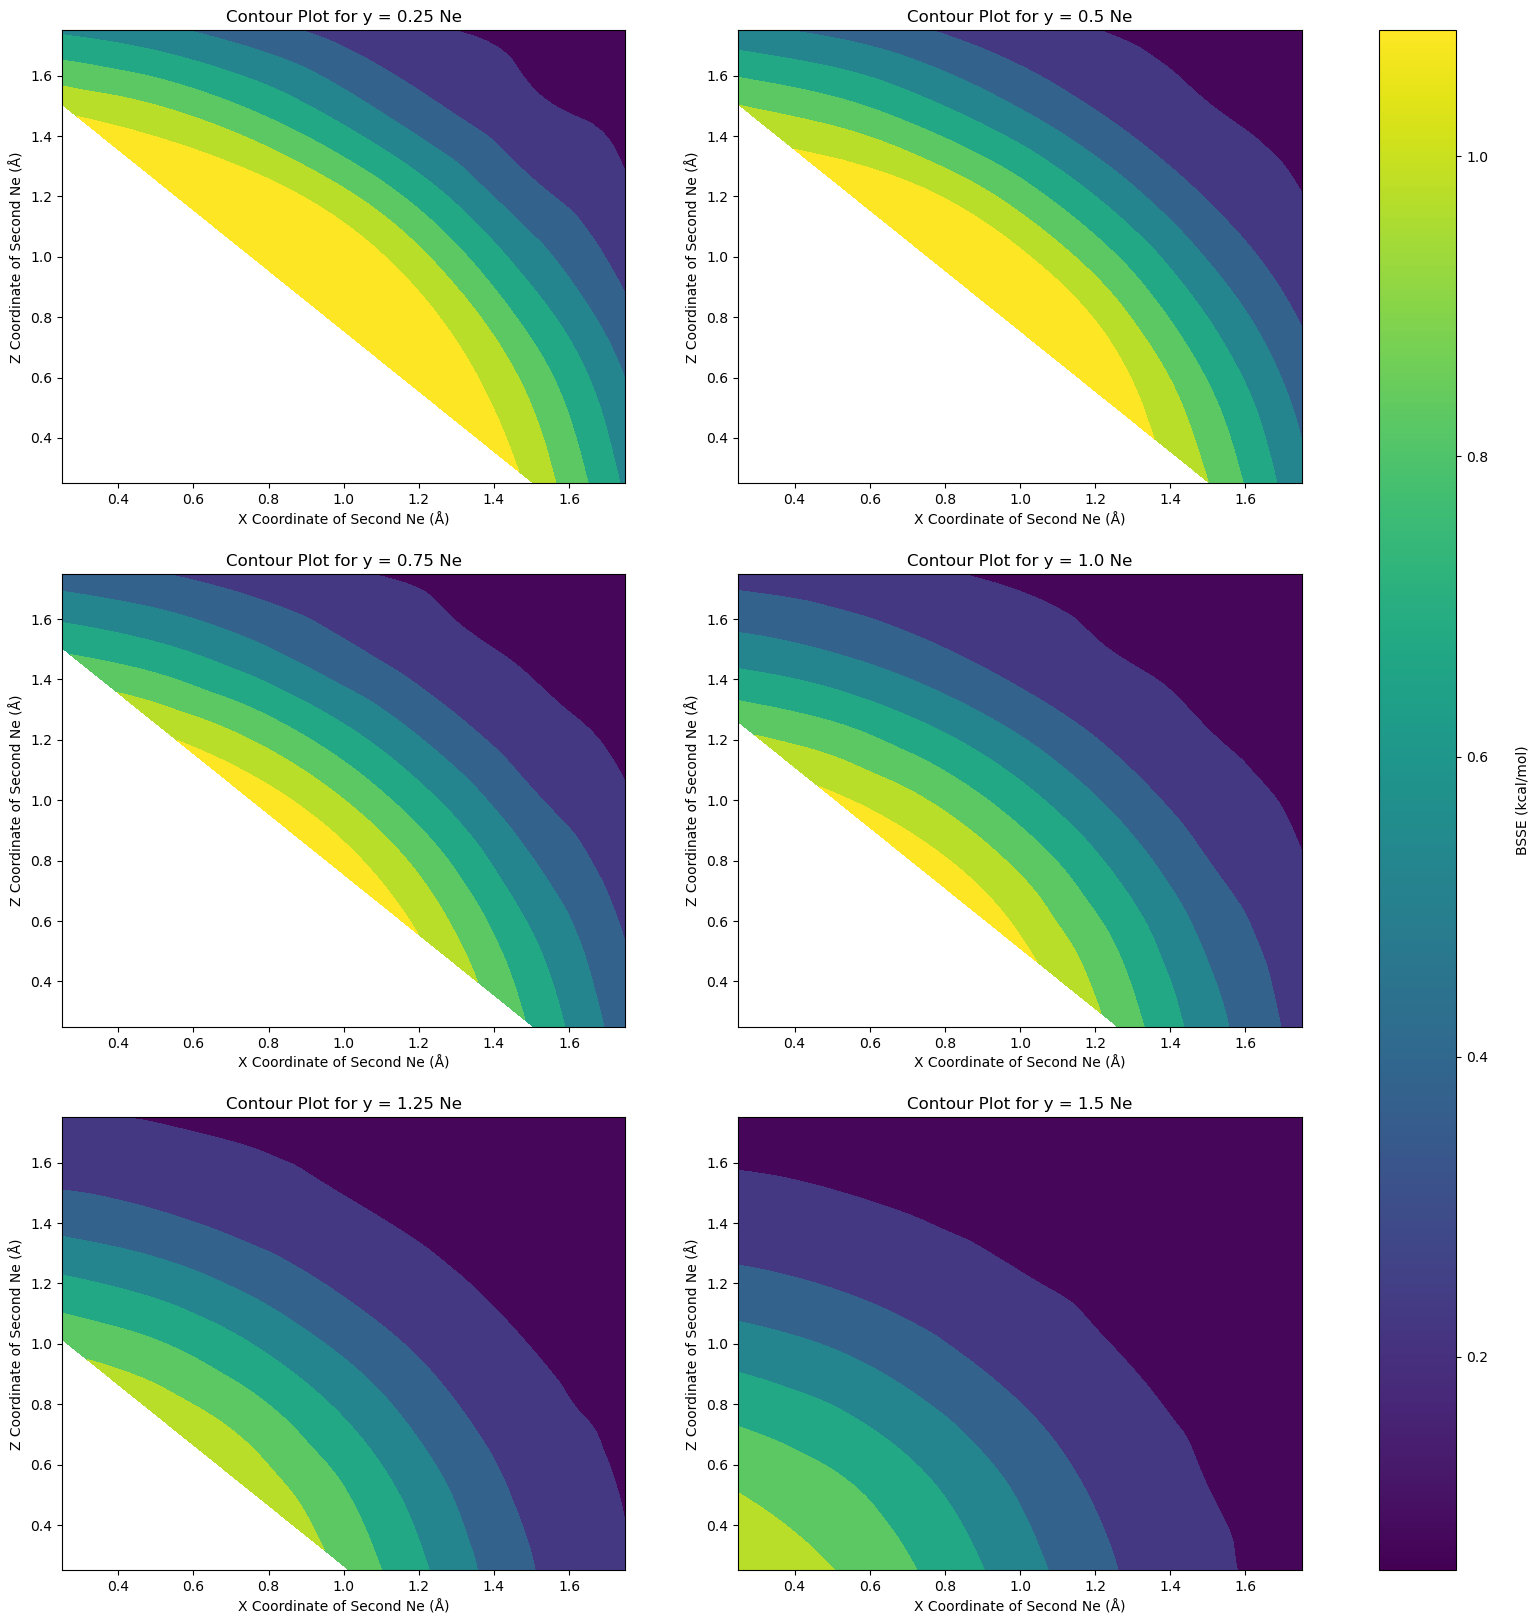

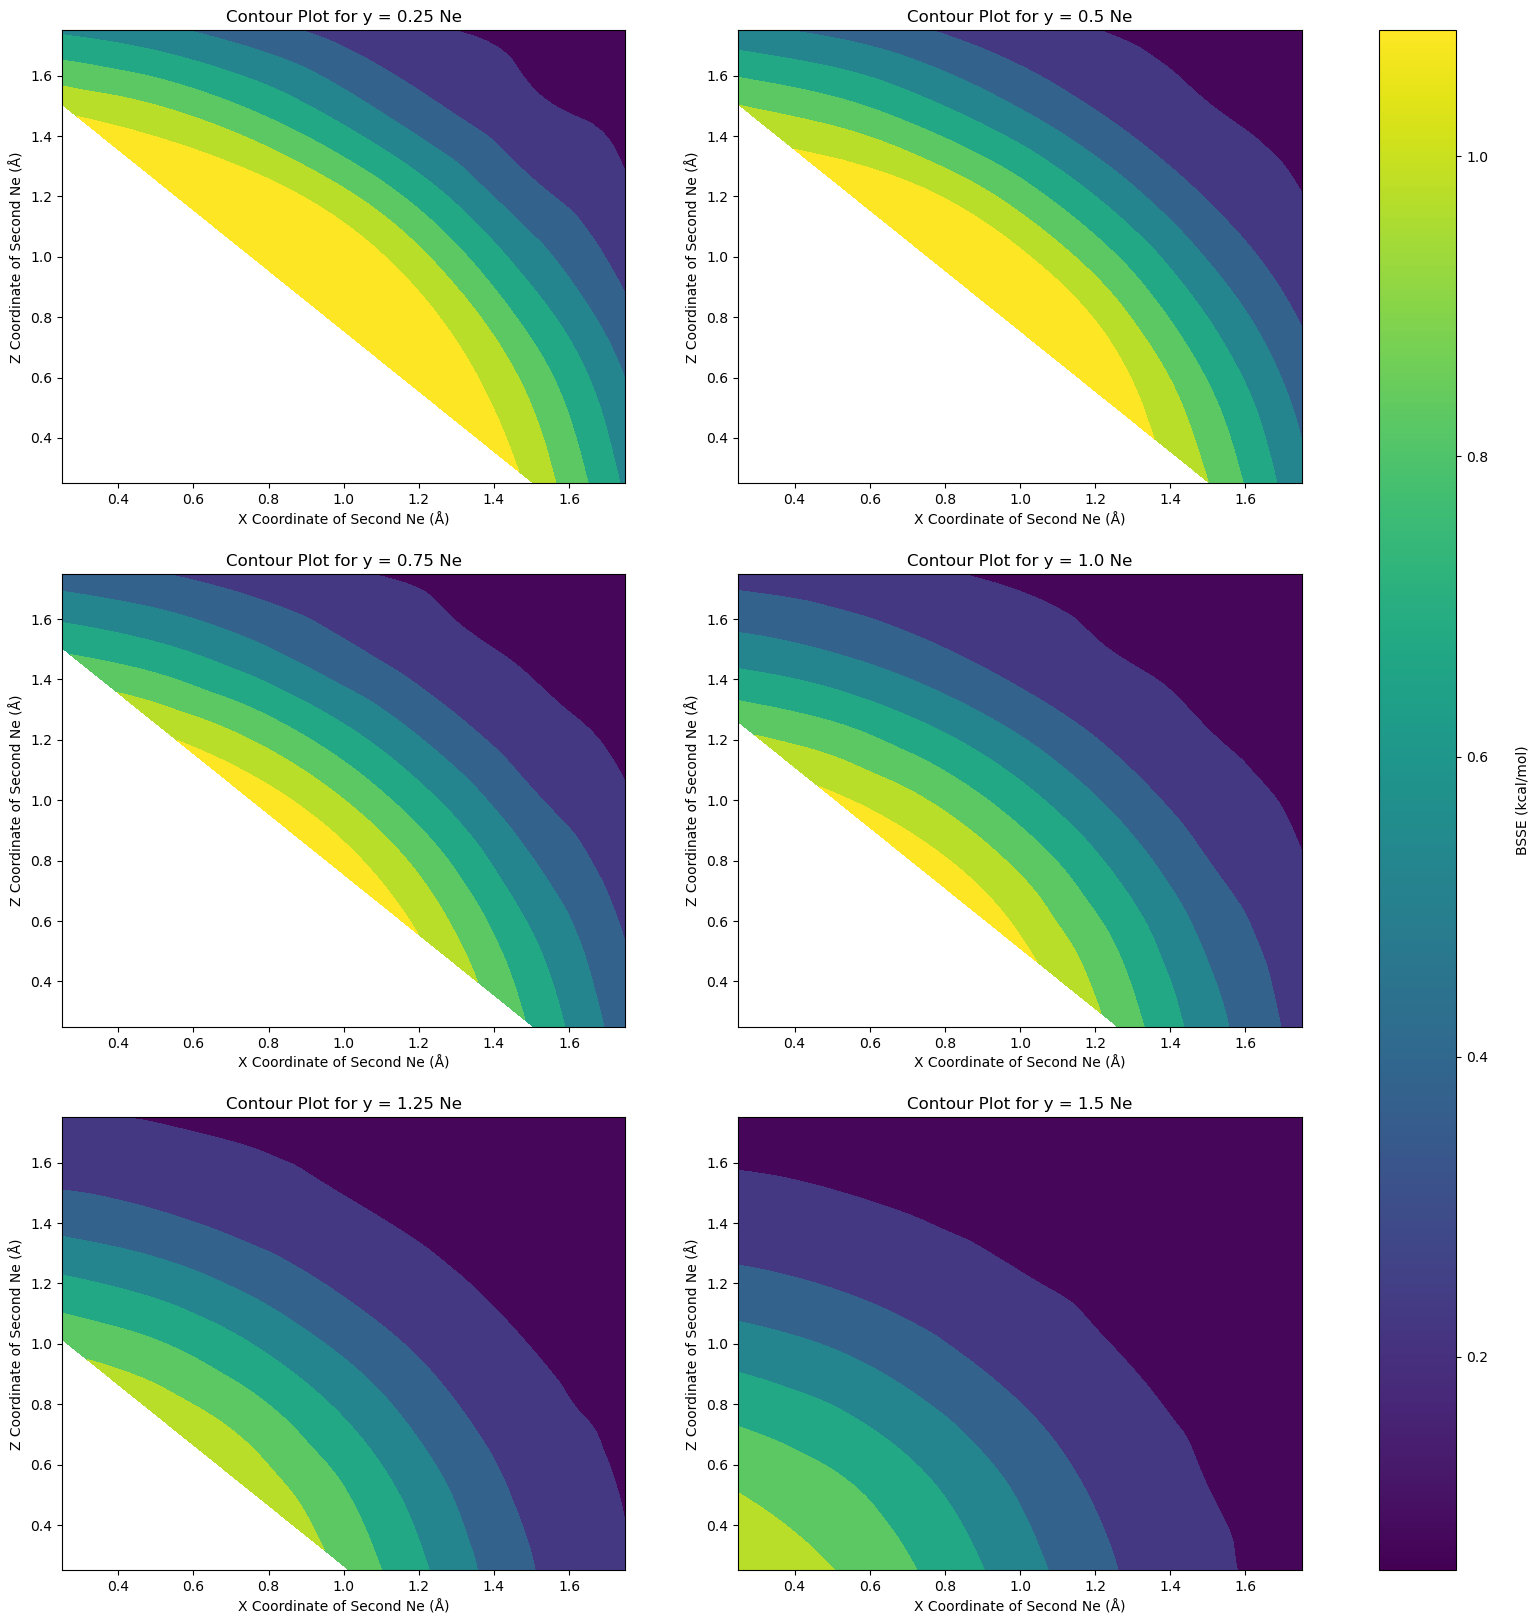

In [15]:
make_bsse_contour_plots(total_energies, "Ne", "Ne")

In [177]:
total_energies["distance"] = np.sqrt(
    total_energies["x"] ** 2 + total_energies["y"] ** 2 + total_energies["z"] ** 2
)

In [178]:
total_energies

,Delta_E_AB_AB,BSSE_A,BSSE_B,x,y,z,distance
0,75.742250,1.011165,1.011156,0.25,0.25,1.50,1.541104
1,24.375013,0.573916,0.573914,0.25,0.25,1.75,1.785357
2,57.468098,0.903610,0.903612,0.25,0.50,1.50,1.600781
3,19.133891,0.489365,0.489376,0.25,0.50,1.75,1.837117
4,37.024673,0.731124,0.731129,0.25,0.75,1.50,1.695582
...,...,...,...,...,...,...,...
263,0.479599,0.103892,0.103912,1.75,1.75,0.75,2.586020
264,0.300344,0.093129,0.093131,1.75,1.75,1.00,2.669270
265,0.158117,0.079857,0.079854,1.75,1.75,1.25,2.772634
266,0.062010,0.067276,0.067279,1.75,1.75,1.50,2.893959


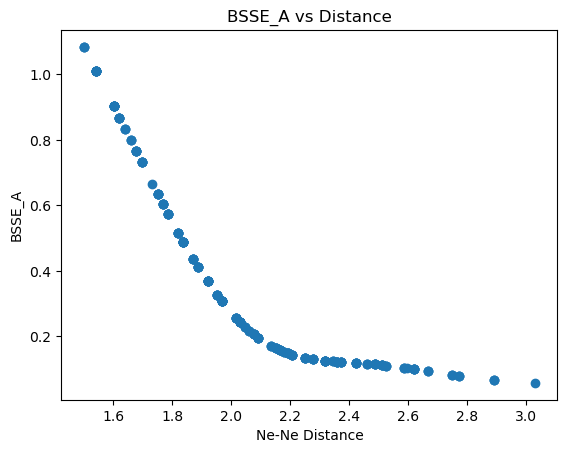

In [179]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(total_energies["distance"], total_energies["BSSE_A"])
ax.set_xlabel("Ne-Ne Distance")
ax.set_ylabel("BSSE_A")
ax.set_title("BSSE_A vs Distance")
plt.show()

In [180]:
bsse_data_nwchem_kcal.columns

Index(['Total_energy_Delta_E_AB_AB', 'Total_energy_BSSE_A',
       'Total_energy_BSSE_B', 'MP2_correlation_energy_Delta_E_AB_AB',
       'MP2_correlation_energy_BSSE_A', 'MP2_correlation_energy_BSSE_B',
       '(T)_correlation_energy_Delta_E_AB_AB', '(T)_correlation_energy_BSSE_A',
       '(T)_correlation_energy_BSSE_B',
       'CCSD_3correlation_energy_Delta_E_AB_AB',
       'CCSD_3correlation_energy_BSSE_A', 'CCSD_3correlation_energy_BSSE_B',
       'SCF_energy_Delta_E_AB_AB', 'SCF_energy_BSSE_A', 'SCF_energy_BSSE_B',
       'x', 'y', 'z'],
      dtype='object')

In [181]:
bsse_data_nwchem_kcal["distance"] = np.sqrt(
    bsse_data_nwchem_kcal["x"] ** 2
    + bsse_data_nwchem_kcal["y"] ** 2
    + bsse_data_nwchem_kcal["z"] ** 2
)

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Read the CSV file
df = bsse_data_nwchem_kcal

# Define the energy types and their corresponding BSSE_A columns
energy_types = {
    "Total Energy": "Total_energy_BSSE_A",
    "SCF Energy": "SCF_energy_BSSE_A",
    "MP2 Correlation": "MP2_correlation_energy_BSSE_A",
    "CCSD Correlation": "CCSD corr.energy_BSSE_A",
    "(T) Correlation": "(T)_correlation_energy_BSSE_A",
}

# Create separate subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten for easier indexing

# Define colors for each energy type
colors = ["blue", "red", "green", "orange", "purple"]

# Plot each energy type in separate subplot
for i, (label, column) in enumerate(energy_types.items()):
    if column in df.columns and i < len(axes):
        ax = axes[i]

        # Remove any NaN values
        mask = ~(df["distance"].isna() | df[column].isna())
        x = df.loc[mask, "distance"].values
        y = df.loc[mask, column].values

        if len(x) > 0:  # Only plot if we have data
            # Plot scatter points
            ax.scatter(x, y, color=colors[i], alpha=0.7, s=50)

            # Fit linear regression
            if len(x) > 1:  # Need at least 2 points for linear fit
                X = x.reshape(-1, 1)
                reg = LinearRegression().fit(X, y)

                # Generate fitted line
                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = reg.predict(x_fit.reshape(-1, 1))

                # Calculate R-squared
                y_pred = reg.predict(X)
                r2 = r2_score(y, y_pred)

                # Plot fitted line
                ax.plot(x_fit, y_fit, color=colors[i], linestyle="--", linewidth=2)

                # Customize individual subplot
                ax.set_xlabel("Distance", fontsize=10)
                ax.set_ylabel("BSSE_A", fontsize=10)
                ax.set_title(f"{label}\nR² = {r2:.3f}", fontsize=11)
                ax.grid(True, alpha=0.3)

# Hide the last subplot if we have fewer than 6 energy types
if len(energy_types) < len(axes):
    axes[-1].axis("off")

# Adjust layout
plt.tight_layout()
fig.suptitle("BSSE by Component")
plt.tight_layout()
# Show the plot
plt.show()

# Optional: Save the plot
# plt.savefig('energy_delta_separate_plots.png', dpi=300, bbox_inches='tight')

KeyboardInterrupt: 

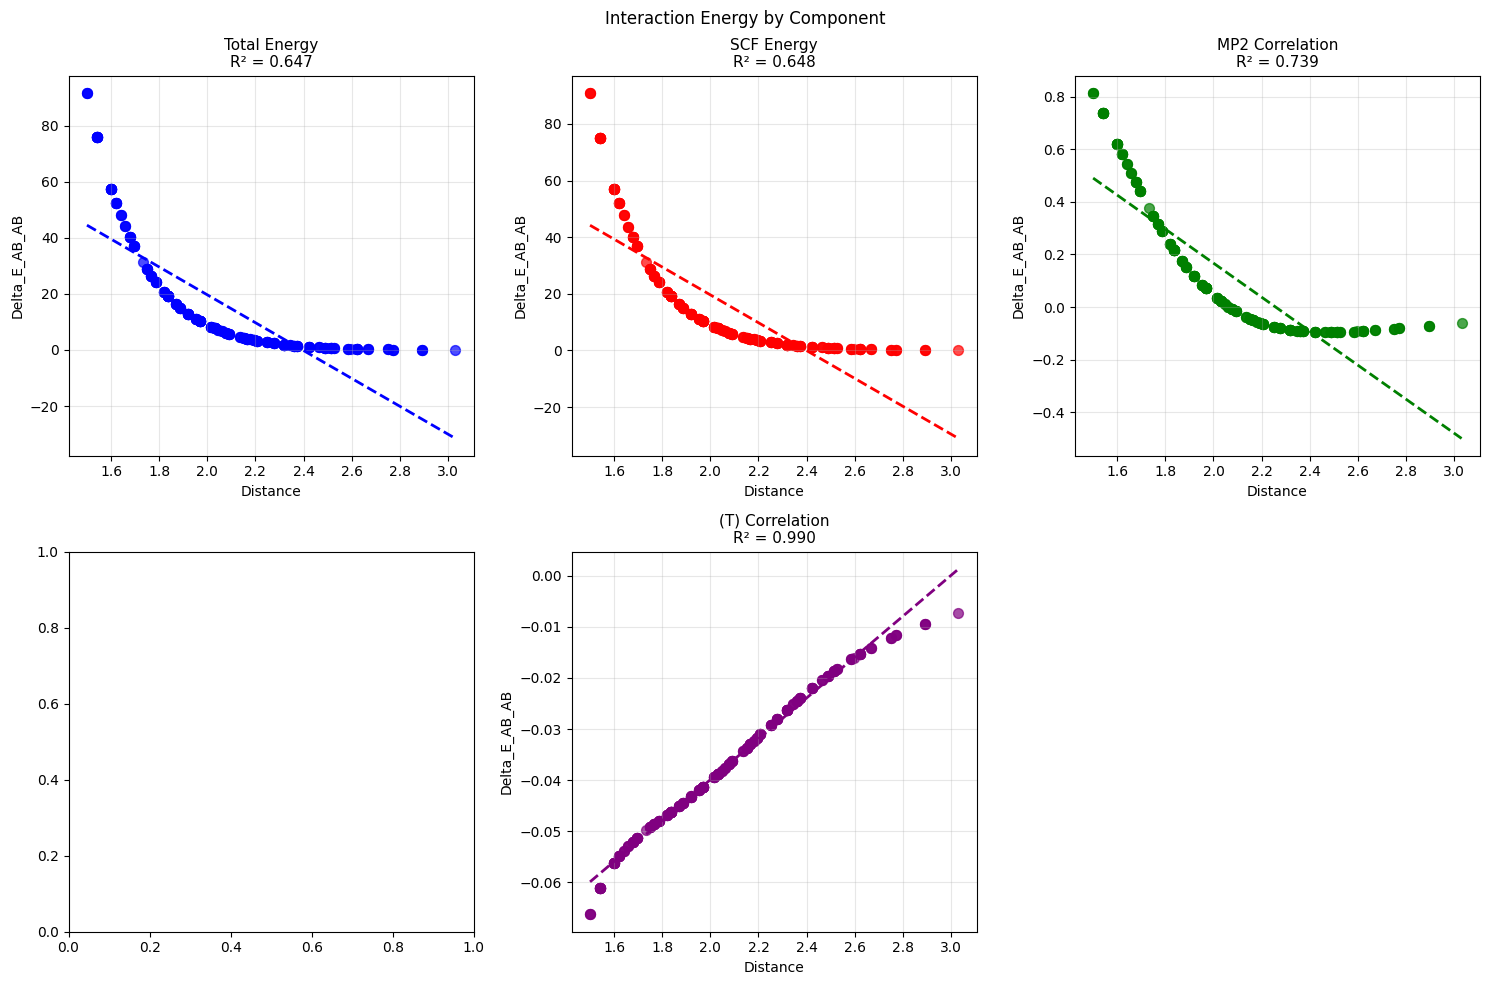

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Read the CSV file
df = bsse_data_nwchem_kcal

# Define the energy types and their corresponding Delta_E_AB_AB columns
energy_types = {
    "Total Energy": "Total_energy_Delta_E_AB_AB",
    "SCF Energy": "SCF_energy_Delta_E_AB_AB",
    "MP2 Correlation": "MP2_correlation_energy_Delta_E_AB_AB",
    "CCSD Correlation": "CCSD corr.energy_Delta_E_AB_AB",
    "(T) Correlation": "(T)_correlation_energy_Delta_E_AB_AB",
}

# Create separate subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten for easier indexing

# Define colors for each energy type
colors = ["blue", "red", "green", "orange", "purple"]

# Plot each energy type in separate subplot
for i, (label, column) in enumerate(energy_types.items()):
    if column in df.columns and i < len(axes):
        ax = axes[i]

        # Remove any NaN values
        mask = ~(df["distance"].isna() | df[column].isna())
        x = df.loc[mask, "distance"].values
        y = df.loc[mask, column].values

        if len(x) > 0:  # Only plot if we have data
            # Plot scatter points
            ax.scatter(x, y, color=colors[i], alpha=0.7, s=50)

            # Fit linear regression
            if len(x) > 1:  # Need at least 2 points for linear fit
                X = x.reshape(-1, 1)
                reg = LinearRegression().fit(X, y)

                # Generate fitted line
                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = reg.predict(x_fit.reshape(-1, 1))

                # Calculate R-squared
                y_pred = reg.predict(X)
                r2 = r2_score(y, y_pred)

                # Plot fitted line
                ax.plot(x_fit, y_fit, color=colors[i], linestyle="--", linewidth=2)

                # Customize individual subplot
                ax.set_xlabel("Distance", fontsize=10)
                ax.set_ylabel("Delta_E_AB_AB", fontsize=10)
                ax.set_title(f"{label}\nR² = {r2:.3f}", fontsize=11)
                ax.grid(True, alpha=0.3)

                # Print fit parameters
                # print(f"{label}:")
                # print(f"  Slope: {reg.coef_[0]:.6f}")
                # print(f"  Intercept: {reg.intercept_:.6f}")
                # print(f"  R²: {r2:.6f}")
                # print()

# Hide the last subplot if we have fewer than 6 energy types
if len(energy_types) < len(axes):
    axes[-1].axis("off")

# Adjust layout
plt.tight_layout()
fig.suptitle("Interaction Energy by Component")
plt.tight_layout()
# Show the plot
plt.show()

# Optional: Save the plot
# plt.savefig('energy_delta_separate_plots.png', dpi=300, bbox_inches='tight')

In [ ]:
bsse_data_nwchem_kcal

,Total_energy_Delta_E_AB_AB,Total_energy_BSSE_A,Total_energy_BSSE_B,MP2_correlation_energy_Delta_E_AB_AB,MP2_correlation_energy_BSSE_A,MP2_correlation_energy_BSSE_B,(T)_correlation_energy_Delta_E_AB_AB,(T)_correlation_energy_BSSE_A,(T)_correlation_energy_BSSE_B,CCSD_3correlation_energy_Delta_E_AB_AB,CCSD_3correlation_energy_BSSE_A,CCSD_3correlation_energy_BSSE_B,SCF_energy_Delta_E_AB_AB,SCF_energy_BSSE_A,SCF_energy_BSSE_B,x,y,z,distance
0,75.742250,1.011165,1.011156,0.738321,0.560166,0.560166,-0.061181,0.046903,0.046901,-0.106711,0.024971,0.024963,75.171821,0.379125,0.379125,0.25,0.25,1.50,1.541104
1,24.375013,0.573916,0.573914,0.290265,0.244499,0.244499,-0.047930,0.032297,0.032297,-0.148225,0.021546,0.021544,24.280903,0.275574,0.275574,0.25,0.25,1.75,1.785357
2,57.468098,0.903610,0.903612,0.620936,0.470642,0.470642,-0.056144,0.042570,0.042570,-0.134250,0.024576,0.024577,57.037556,0.365822,0.365822,0.25,0.50,1.50,1.600781
3,19.133891,0.489365,0.489376,0.216655,0.199751,0.199751,-0.046157,0.030030,0.030030,-0.141067,0.019699,0.019710,19.104459,0.239884,0.239884,0.25,0.50,1.75,1.837117
4,37.024673,0.731124,0.731129,0.439585,0.342533,0.342533,-0.051223,0.036788,0.036789,-0.151427,0.023622,0.023626,36.787738,0.328182,0.328182,0.25,0.75,1.50,1.695582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,0.479599,0.103892,0.103912,-0.092817,0.038799,0.038799,-0.016383,0.009738,0.009740,-0.021402,0.005078,0.005097,0.610201,0.050276,0.050276,1.75,1.75,0.75,2.586020
264,0.300344,0.093129,0.093131,-0.088271,0.036508,0.036508,-0.014090,0.009167,0.009167,-0.016861,0.005454,0.005457,0.419565,0.041999,0.041999,1.75,1.75,1.00,2.669270
265,0.158117,0.079857,0.079854,-0.081137,0.034952,0.034952,-0.011690,0.008659,0.008658,-0.012509,0.005496,0.005494,0.263452,0.030750,0.030750,1.75,1.75,1.25,2.772634
266,0.062010,0.067276,0.067279,-0.071867,0.034002,0.034002,-0.009408,0.008138,0.008139,-0.008777,0.005091,0.005092,0.152062,0.020046,0.020046,1.75,1.75,1.50,2.893959


In [ ]:
label = "Total Energy"

In [ ]:
df.columns

Index(['Total_energy_Delta_E_AB_AB', 'Total_energy_BSSE_A',
       'Total_energy_BSSE_B', 'MP2_correlation_energy_Delta_E_AB_AB',
       'MP2_correlation_energy_BSSE_A', 'MP2_correlation_energy_BSSE_B',
       '(T)_correlation_energy_Delta_E_AB_AB', '(T)_correlation_energy_BSSE_A',
       '(T)_correlation_energy_BSSE_B',
       'CCSD_3correlation_energy_Delta_E_AB_AB',
       'CCSD_3correlation_energy_BSSE_A', 'CCSD_3correlation_energy_BSSE_B',
       'SCF_energy_Delta_E_AB_AB', 'SCF_energy_BSSE_A', 'SCF_energy_BSSE_B',
       'x', 'y', 'z', 'distance'],
      dtype='object')

In [ ]:
col = df.columns[1]

In [ ]:
col.replace("_", " ").title()

'Total Energy Bsse A'

In [ ]:
label.title()

'Total Energy'

In [ ]:
label.title() in col.replace("_", " ").title() and "Bsse" in col

False

In [ ]:
label.title() in col.replace("_", " ").title()

True

In [ ]:
col.replace("_", " ").title()

'Total Energy Bsse A'

In [ ]:
"Bsse" in col

False

In [ ]:
[
    col
    for col in df.columns
    if label.title() in col.replace("_", " ").title() and "BSSE" in col
][0]

'Total_energy_BSSE_A'

In [ ]:
label

'Total Energy'

In [35]:
df.rename(columns={})

,Total_energy_Delta_E_AB_AB,Total_energy_BSSE_A,Total_energy_BSSE_B,MP2_correlation_energy_Delta_E_AB_AB,MP2_correlation_energy_BSSE_A,MP2_correlation_energy_BSSE_B,(T)_correlation_energy_Delta_E_AB_AB,(T)_correlation_energy_BSSE_A,(T)_correlation_energy_BSSE_B,CCSD_3correlation_energy_Delta_E_AB_AB,CCSD_3correlation_energy_BSSE_A,CCSD_3correlation_energy_BSSE_B,SCF_energy_Delta_E_AB_AB,SCF_energy_BSSE_A,SCF_energy_BSSE_B,x,y,z,distance
0,75.742250,1.011165,1.011156,0.738321,0.560166,0.560166,-0.061181,0.046903,0.046901,-0.106711,0.024971,0.024963,75.171821,0.379125,0.379125,0.25,0.25,1.50,1.541104
1,24.375013,0.573916,0.573914,0.290265,0.244499,0.244499,-0.047930,0.032297,0.032297,-0.148225,0.021546,0.021544,24.280903,0.275574,0.275574,0.25,0.25,1.75,1.785357
2,57.468098,0.903610,0.903612,0.620936,0.470642,0.470642,-0.056144,0.042570,0.042570,-0.134250,0.024576,0.024577,57.037556,0.365822,0.365822,0.25,0.50,1.50,1.600781
3,19.133891,0.489365,0.489376,0.216655,0.199751,0.199751,-0.046157,0.030030,0.030030,-0.141067,0.019699,0.019710,19.104459,0.239884,0.239884,0.25,0.50,1.75,1.837117
4,37.024673,0.731124,0.731129,0.439585,0.342533,0.342533,-0.051223,0.036788,0.036789,-0.151427,0.023622,0.023626,36.787738,0.328182,0.328182,0.25,0.75,1.50,1.695582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,0.479599,0.103892,0.103912,-0.092817,0.038799,0.038799,-0.016383,0.009738,0.009740,-0.021402,0.005078,0.005097,0.610201,0.050276,0.050276,1.75,1.75,0.75,2.586020
264,0.300344,0.093129,0.093131,-0.088271,0.036508,0.036508,-0.014090,0.009167,0.009167,-0.016861,0.005454,0.005457,0.419565,0.041999,0.041999,1.75,1.75,1.00,2.669270
265,0.158117,0.079857,0.079854,-0.081137,0.034952,0.034952,-0.011690,0.008659,0.008658,-0.012509,0.005496,0.005494,0.263452,0.030750,0.030750,1.75,1.75,1.25,2.772634
266,0.062010,0.067276,0.067279,-0.071867,0.034002,0.034002,-0.009408,0.008138,0.008139,-0.008777,0.005091,0.005092,0.152062,0.020046,0.020046,1.75,1.75,1.50,2.893959


IndexError: list index out of range

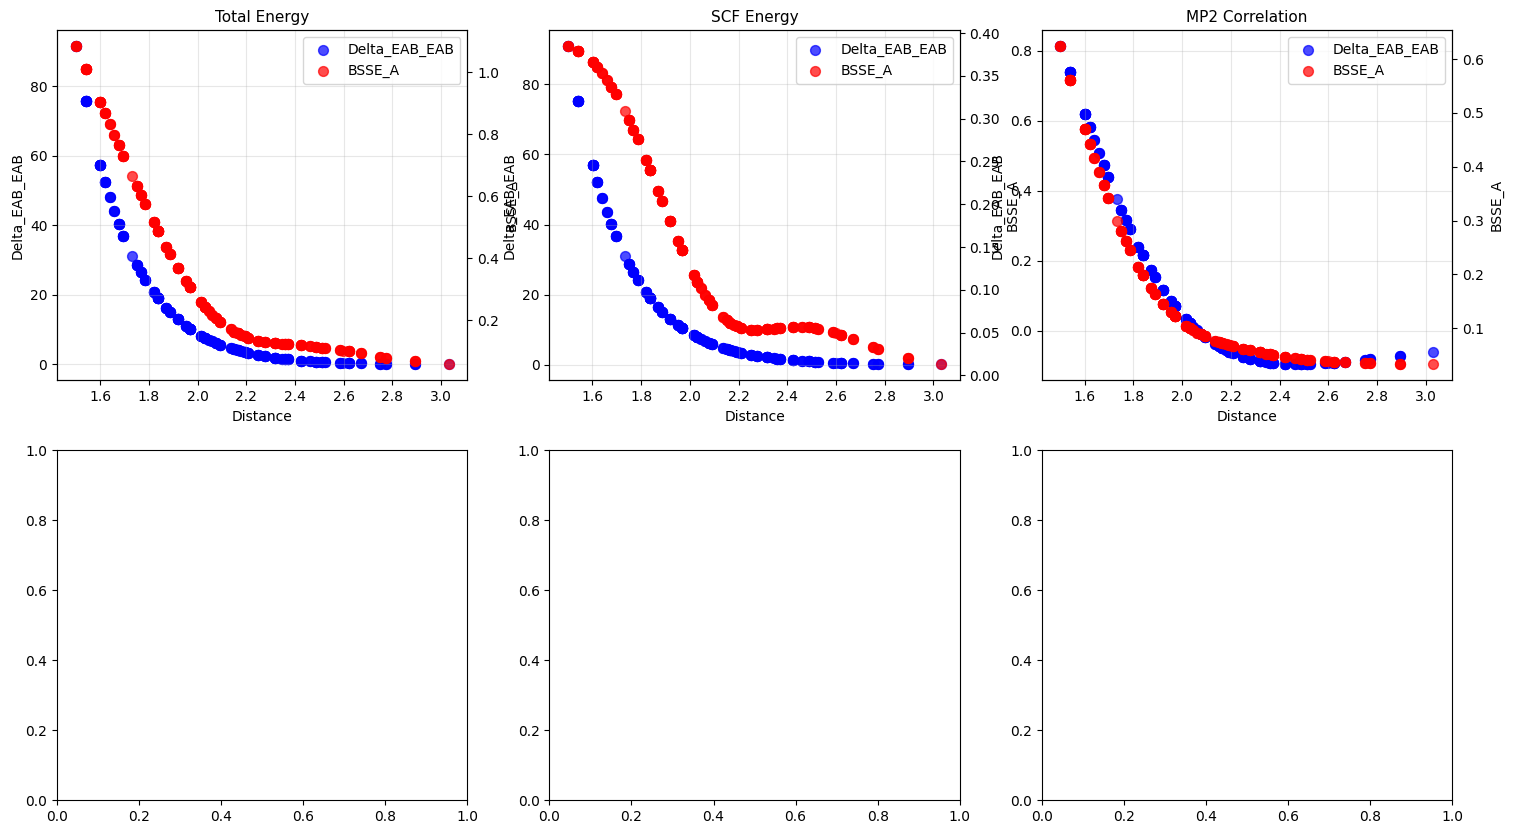

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
df = bsse_data_nwchem_kcal

# Define the energy types and their corresponding columns
energy_types = [
    "Total Energy",
    "SCF Energy",
    "MP2 Correlation",
    "CCSD Correlation",
    "(T) Correlation",
]

# Create separate subplots with dual y-axes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Flatten for easier indexing

# Define colors
delta_color = "blue"
bsse_color = "red"

# Plot each energy type in separate subplot with dual y-axis
for i, label in enumerate(energy_types):
    delta_col = [
        col
        for col in df.columns
        if label.title() in col.replace("_", " ").title() and "Delta" in col
    ][0]
    bsse_col = [
        col
        for col in df.columns
        if label.title() in col.replace("_", " ").title() and "BSSE" in col
    ][0]
    if i < len(axes):
        ax1 = axes[i]

        # Remove any NaN values
        x = df.loc[mask, "distance"].values
        y_delta = df.loc[mask, delta_col].values
        y_bsse = df.loc[mask, bsse_col].values
        line1 = ax1.scatter(
            x, y_delta, color=delta_color, alpha=0.7, s=50, label="Delta_EAB_EAB"
        )
        ax1.set_xlabel("Distance", fontsize=10)
        ax1.set_ylabel("Delta_EAB_EAB", fontsize=10)

        # Create secondary y-axis (right)
        ax2 = ax1.twinx()
        line2 = ax2.scatter(
            x, y_bsse, color=bsse_color, alpha=0.7, s=50, label="BSSE_A"
        )
        ax2.set_ylabel("BSSE_A", fontsize=10)

        # Set title
        ax1.set_title(f"{label}", fontsize=11)

        # Add grid to primary axis
        ax1.grid(True, alpha=0.3)

        # Add legend
        lines = [line1, line2]
        labels = ["Delta_EAB_EAB", "BSSE_A"]
        ax1.legend(lines, labels, loc="upper right")

# Hide the last subplot if we have fewer than 6 energy types
if len(energy_types) < len(axes):
    axes[-1].axis("off")

# Adjust layout
plt.tight_layout()
fig.suptitle("Delta_EAB_EAB vs BSSE_A by Energy Component", fontsize=14, y=1.02)

# Show the plot
plt.show()

# Optional: Save the plot
# plt.savefig('delta_vs_bsse_dual_axis_plots.png', dpi=300, bbox_inches='tight')

In [ ]:
total_energies[(total_energies["distance"] > 3.4) & (total_energies["distance"] < 3.6)]

In [7]:
fit_gauss = fit_gaussian(total_energies, 1)

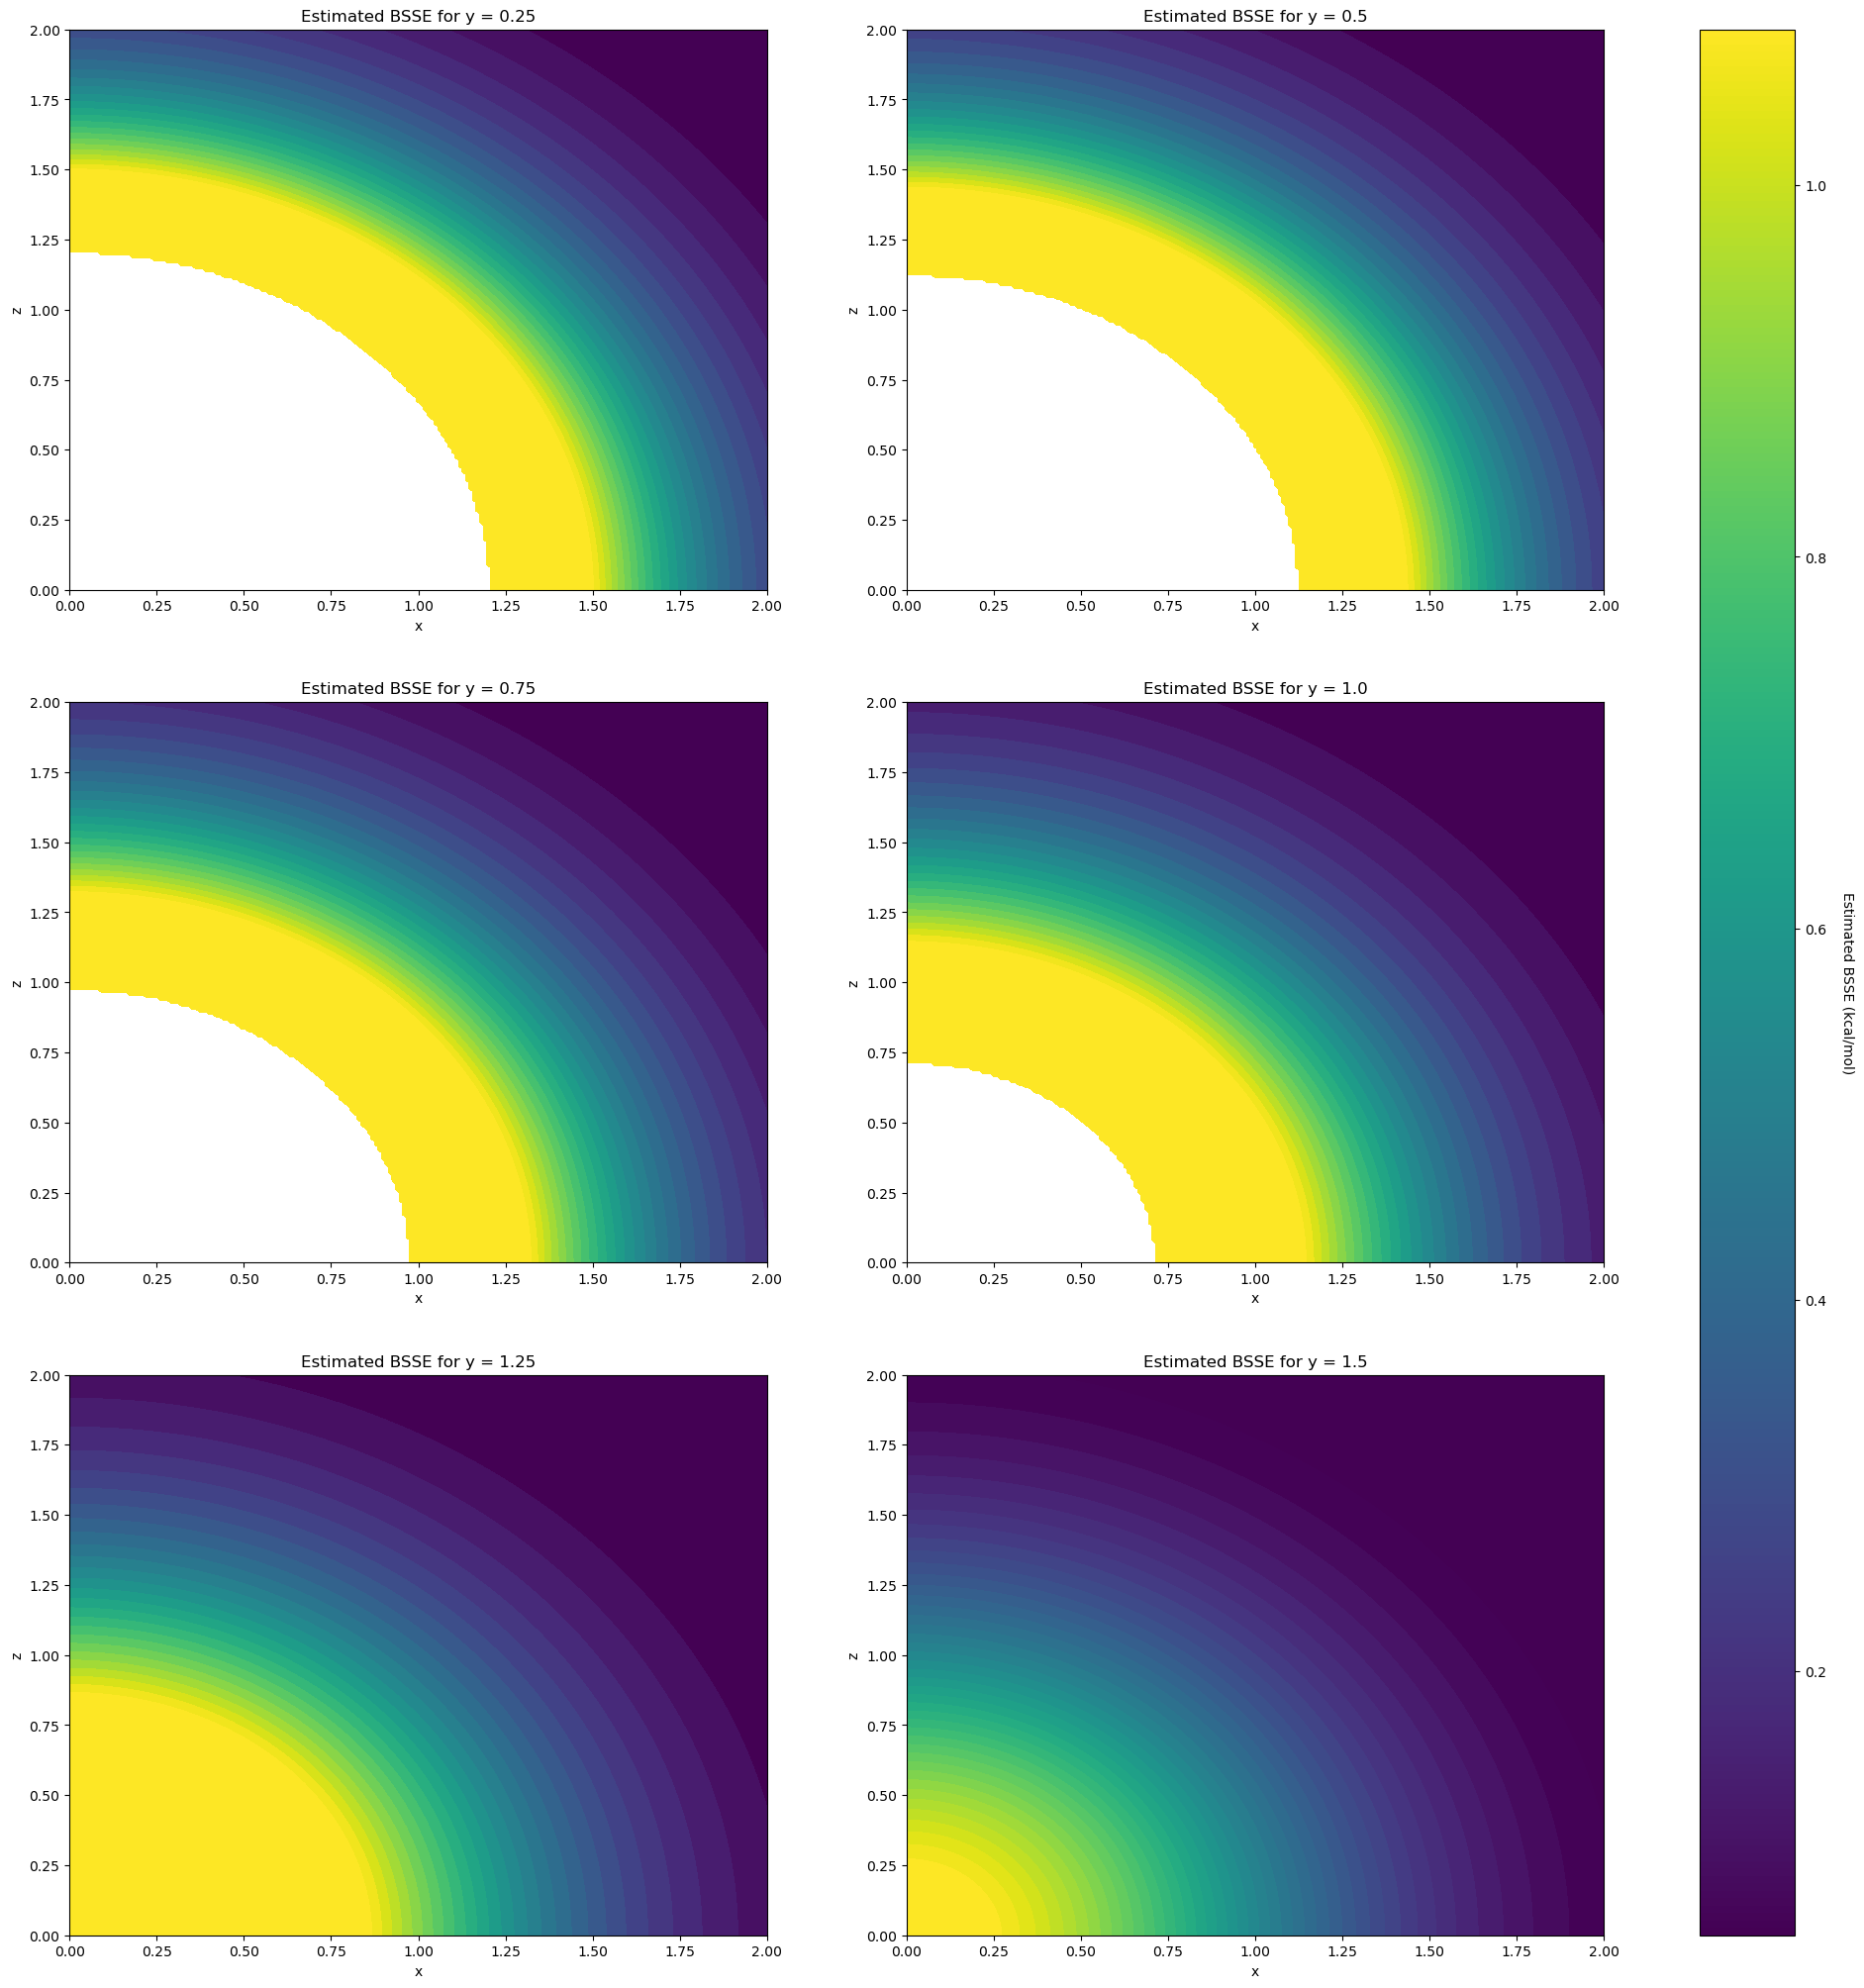

In [8]:
make_contour_plots_of_fitted_gaussian(total_energies, fit_gauss)

In [ ]:
predicted_v_actual_plot(total_energies, fit_gauss)

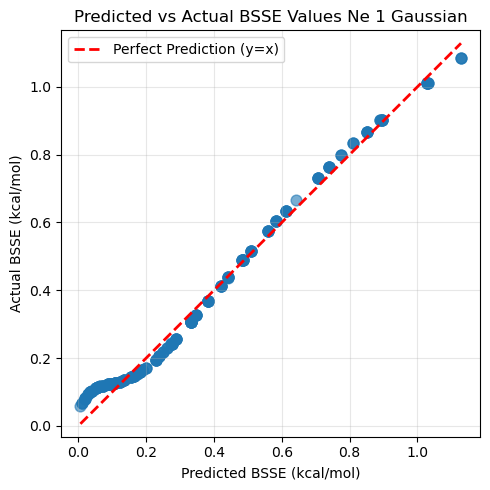

{'RMSE': np.float64(0.031624295468100465), 'MAE': np.float64(0.026509035950087283), '% Error': np.float64(17.046188910270843)}


/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:75: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


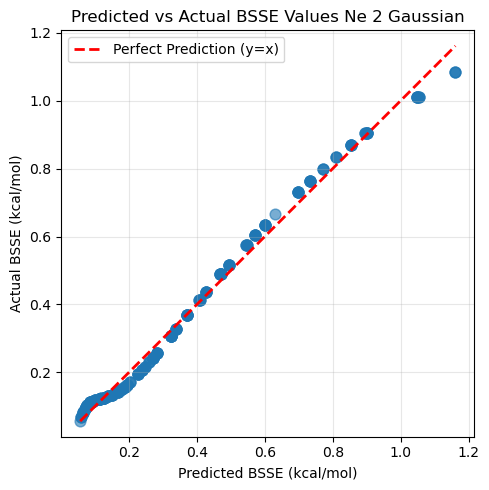

{'RMSE': np.float64(0.024390334419394723), 'MAE': np.float64(0.02125378222614864), '% Error': np.float64(9.710947024174159)}


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.

In [13]:
for i in range(1, 4):
    fit_gauss = fit_gaussian(total_energies, i)
    print(predicted_v_actual_plot(total_energies, fit_gauss, f"Ne {i} Gaussian"))

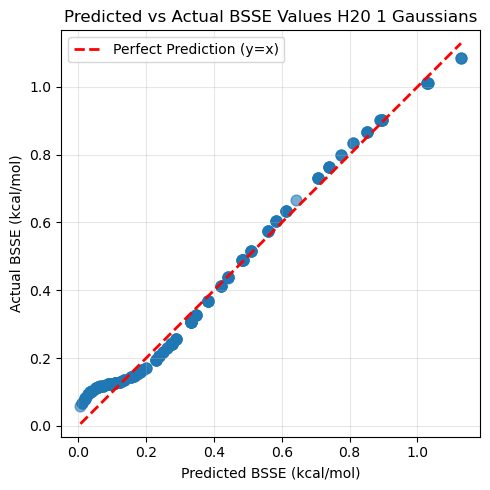

{'RMSE': np.float64(0.031624295468100465),
 'MAE': np.float64(0.026509035950087283),
 '% Error': np.float64(17.046188910270843)}

In [11]:
predicted_v_actual_plot(total_energies, fit_gauss, f"H20 1 Gaussians")

NameError: name 'bsse_data_nwchem_kcal' is not defined

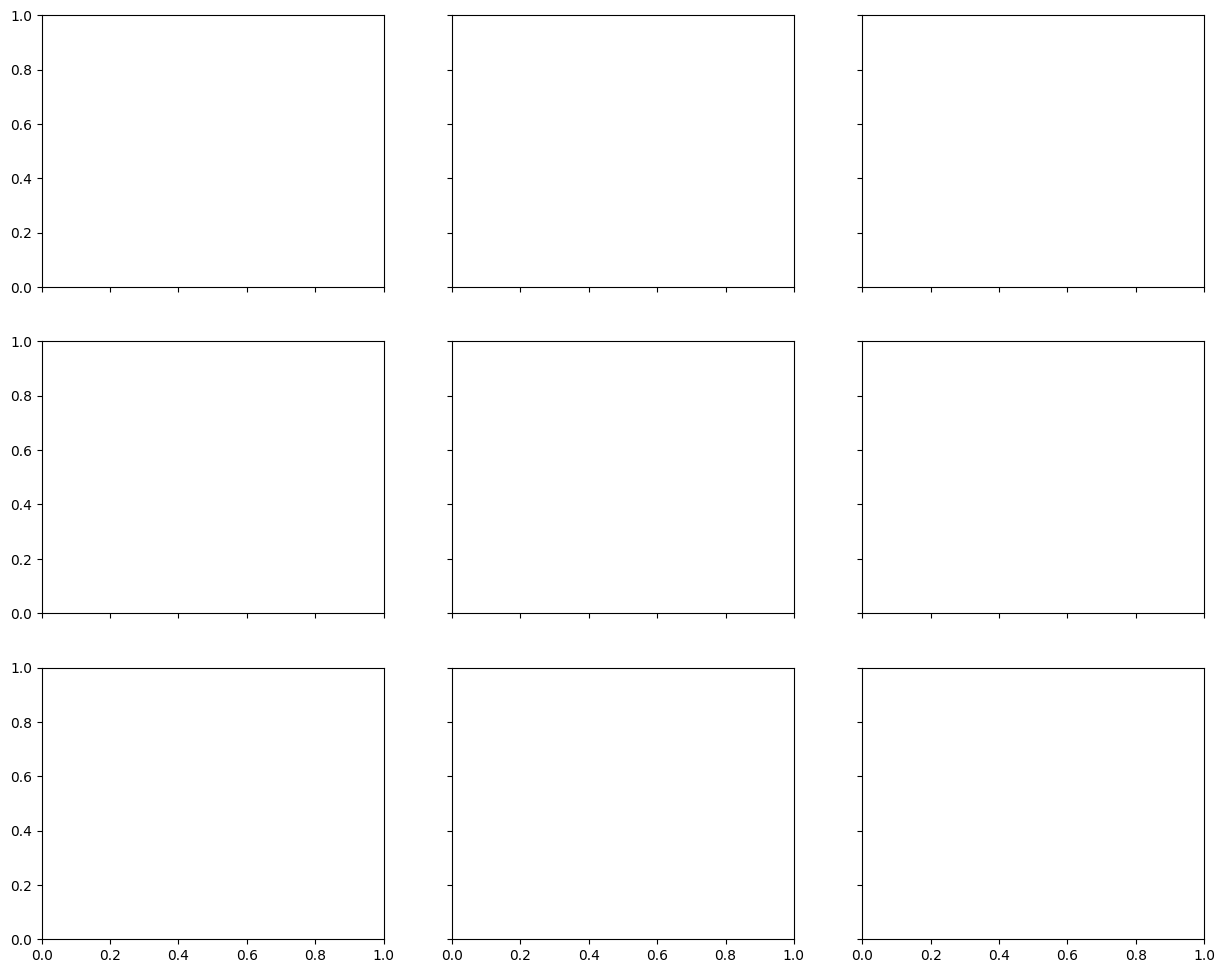

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

# Define x and y grid values
x_vals = np.arange(0.5, 2, 0.5)
y_vals = np.arange(0.5, 2, 0.5)

nrows = len(y_vals)
ncols = len(x_vals)

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True, sharey=True
)
axes = np.atleast_2d(axes)

cols = [
    "SCF_energy_BSSE_A",
    "MP2_correlation_energy_BSSE_A",
    "(T)_correlation_energy_BSSE_A",
    "CCSD corr.energy_BSSE_A",
]

legend_handles, legend_labels = None, None

for i, fixed_y in enumerate(y_vals):
    for j, fixed_x in enumerate(x_vals):
        ax = axes[i, j]
        fixed_x_df = bsse_data_nwchem_kcal[bsse_data_nwchem_kcal["x"] == fixed_x]
        fixed_y_df = fixed_x_df[fixed_x_df["y"] == fixed_y]
        if fixed_y_df.empty or not all(col in fixed_y_df.columns for col in cols):
            ax.axis("off")
            continue

        fixed_y_df = fixed_y_df.set_index("z")
        fixed_y_df[cols].plot(kind="bar", ax=ax, stacked=True, legend=False)
        ax.set_title(f"x={fixed_x}, y={fixed_y}")
        ax.set_xlabel("z")
        ax.set_ylabel("Energy")

        # Capture legend from the first valid plot
        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

# Add global legend if we found any handles
if legend_handles:
    fig.legend(
        legend_handles, legend_labels, title="Energy Terms", loc="upper center", ncol=4
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

NameError: name 'bsse_data_nwchem_kcal' is not defined

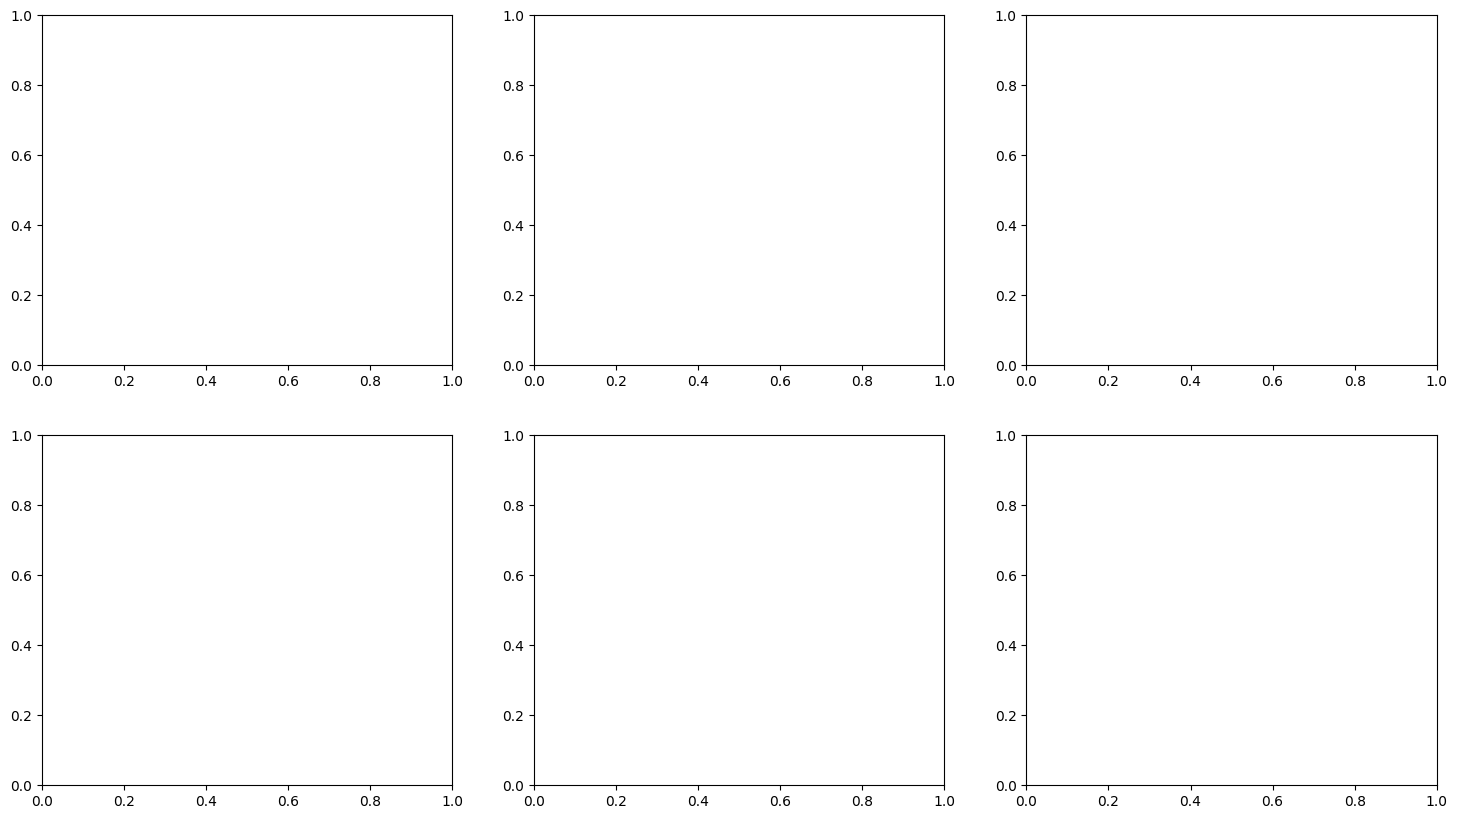

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

energy_types = [
    "Total_energy",
    "SCF_energy",
    "MP2_correlation_energy",
    "(T)_correlation_energy",
    "CCSD corr.energy",
]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, energy_type in enumerate(energy_types):
    ax = axes[i]
    x = abs(bsse_data_nwchem_kcal[f"{energy_type}_Delta_E_AB_AB"])
    y = abs(bsse_data_nwchem_kcal[f"{energy_type}_BSSE_A"])

    # Scatter
    ax.scatter(x, y)

    # Regression line
    slope, intercept = np.polyfit(x, y, 1)
    ax.plot(x, slope * x + intercept, color="red", label="Linear regression")
    ax.set_title(f"{energy_type}", fontsize=14)
    ax.set_xlabel(r"$\Delta E_{\mathrm{AB,AB}}$ " + f"kcal/mol")
    ax.set_ylabel(r"$\mathrm{{BSSE}}_A$ " + f"kcal/mol")
    # ax.legend()

# Hide unused subplot
if len(energy_types) < len(axes):
    for j in range(len(energy_types), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

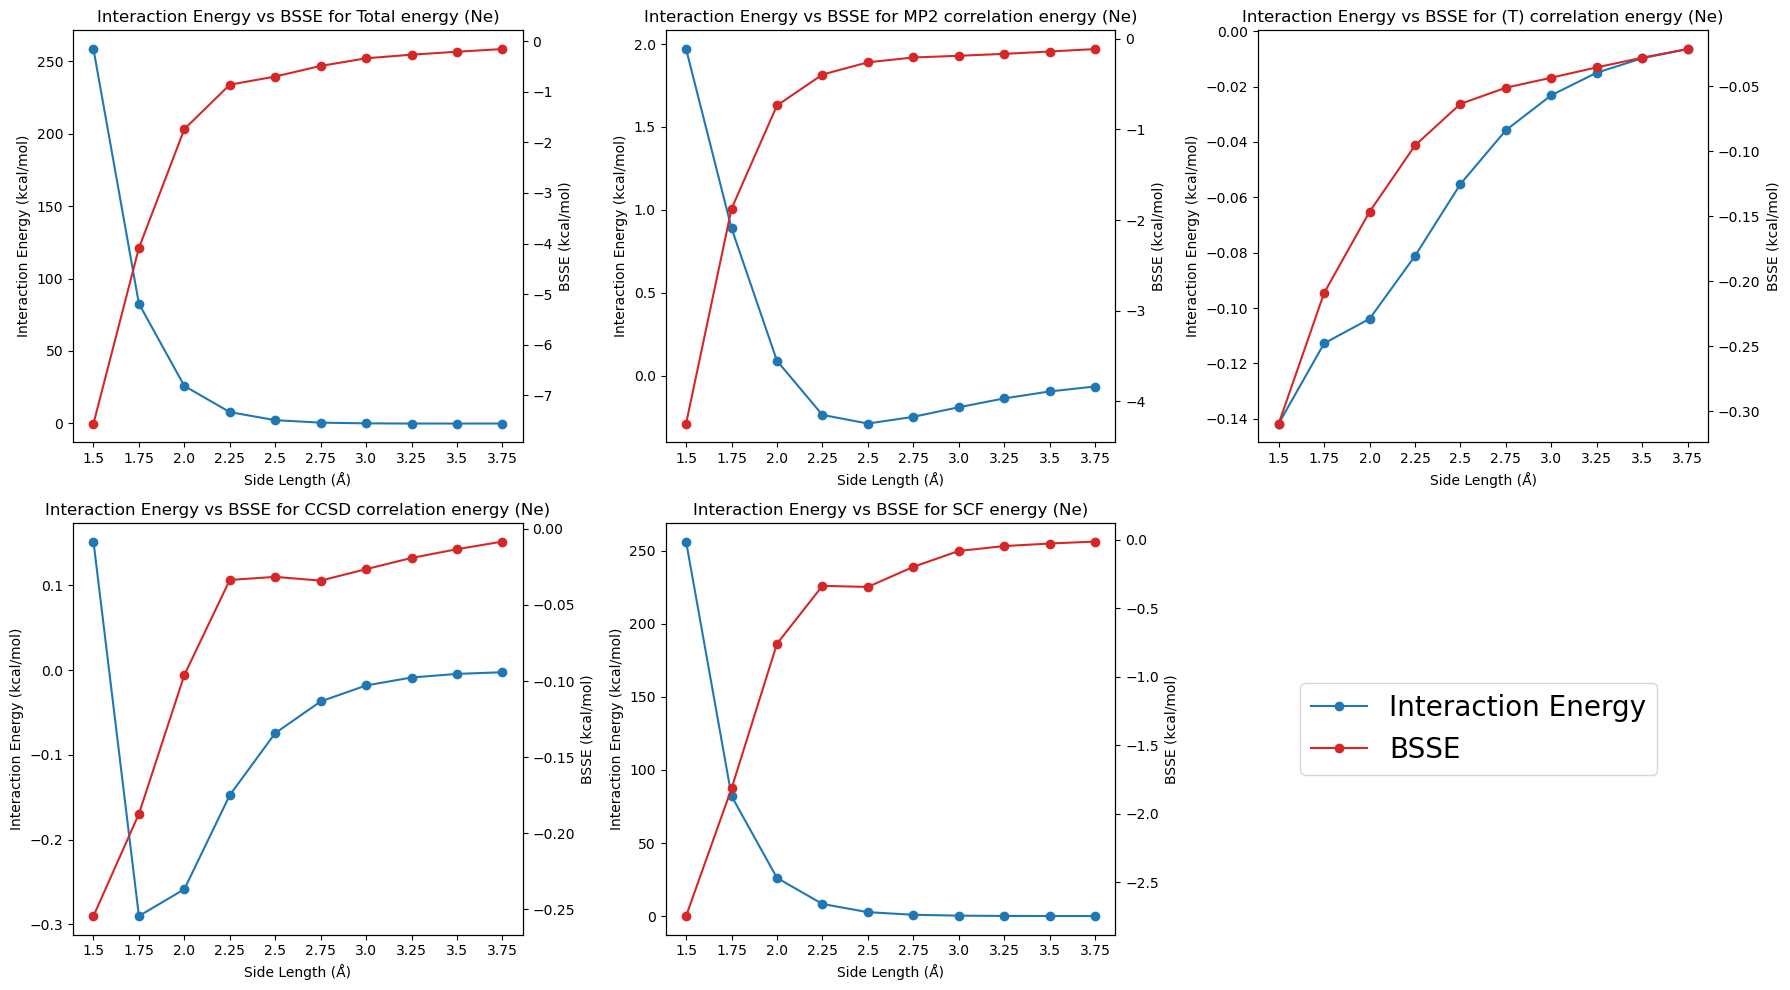

In [ ]:
import json
from bsse_calculator.plotting_helpers import *

energies = json.loads(open("Ne_trimer_energies.json", "r").read())
energy_dfs = create_df(energies)
energy_dfs = {
    k: create_BSSEs_and_interaction_energies(df) for k, df in energy_dfs.items()
}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (k, df) in zip(axes, energy_dfs.items()):
    formated_title = k.replace("_", " ")
    lines, labels = plot_dual_axis(
        df["Total Interaction Energy (BSSE free)"],
        df["Total BSSE"],
        df["side_length"],
        ax1=ax,
        title=f"Interaction Energy vs BSSE for {formated_title} (Ne)",
        x_label="Side Length (Å)",
        y1_label="Interaction Energy (kcal/mol)",
        y2_label="BSSE (kcal/mol)",
        label1="Interaction Energy",
        label2="BSSE",
    )
plt.tight_layout()
ax.legend(
    lines, labels, prop={"size": 20}, loc="center left", bbox_to_anchor=(1.380, 0.5)
)
tfig.delaxes(axes[-1])

In [326]:
energy_dfs["Total_energy"]

,side_length,E(A)_A,E(A)_A_B,E(A)_A_C,E(A)_A_B_C,E(B)_B,E(B)_A_B,E(B)_B_C,E(B)_A_B_C,E(C)_C,...,BSSE_(A_C),Delta_E(BC)_BC,Delta_E(BC)_ABC,BSSE_(B_C),BSSE_(A)_ABC,BSSE_(B)_ABC,BSSE_(C)_ABC,Total Interaction Energy (BSSE free),Total Interaction Energy (w/o BSSE correction),Total BSSE
0,1.5,-80767.572707,-80768.656700,-80768.656700,-80769.713539,-80767.572708,-80768.656738,-80768.656738,-80769.713574,-80767.572708,...,0.377530,91.583386,91.205853,0.377533,2.140831,2.140866,2.140831,258.373534,250.818537,-7.554997
1,1.75,-80767.572707,-80768.207264,-80768.207264,-80768.832985,-80767.572709,-80768.207261,-80768.207299,-80768.832981,-80767.572709,...,0.102241,28.744524,28.642248,0.102277,1.260278,1.260273,1.260277,82.641954,78.554413,-4.087541
2,2.0,-80767.572709,-80767.845722,-80767.845724,-80768.117179,-80767.572705,-80767.845727,-80767.845721,-80768.117177,-80767.572709,...,0.035328,8.867783,8.832468,0.035315,0.544470,0.544472,0.544462,25.847772,24.108384,-1.739388
3,2.25,-80767.572709,-80767.707313,-80767.707300,-80767.841748,-80767.572711,-80767.707313,-80767.707313,-80767.841748,-80767.572709,...,0.018509,2.654881,2.636367,0.018514,0.269039,0.269037,0.269052,7.814406,6.951715,-0.862691
4,2.5,-80767.572709,-80767.685883,-80767.685883,-80767.795865,-80767.572708,-80767.685884,-80767.685886,-80767.795854,-80767.572709,...,0.010545,0.757525,0.746954,0.010571,0.223156,0.223146,0.223146,2.245628,1.544512,-0.701116
5,2.75,-80767.572709,-80767.655337,-80767.655332,-80767.730767,-80767.572709,-80767.655336,-80767.655321,-80767.730767,-80767.572709,...,0.005807,0.183491,0.177639,0.005852,0.158058,0.158058,0.158073,0.546959,0.055283,-0.491676
6,3.0,-80767.572709,-80767.632270,-80767.632259,-80767.683670,-80767.572709,-80767.632256,-80767.632257,-80767.683697,-80767.572709,...,0.002941,0.015617,0.012696,0.002920,0.110961,0.110988,0.110893,0.047121,-0.294446,-0.341566
7,3.25,-80767.572709,-80767.620628,-80767.620628,-80767.661250,-80767.572709,-80767.620621,-80767.620716,-80767.661250,-80767.572709,...,0.001329,-0.025080,-0.026471,0.001390,0.088541,0.088541,0.088541,-0.074961,-0.344615,-0.269654
8,3.5,-80767.572709,-80767.610581,-80767.610591,-80767.642780,-80767.572709,-80767.610588,-80767.610584,-80767.642780,-80767.572718,...,0.000546,-0.028131,-0.028678,0.000547,0.070071,0.070071,0.070059,-0.084143,-0.295982,-0.211839
9,3.75,-80767.572709,-80767.601013,-80767.601022,-80767.625382,-80767.572709,-80767.601022,-80767.601020,-80767.625386,-80767.572729,...,0.000187,-0.022337,-0.022541,0.000204,0.052673,0.052677,0.052668,-0.066907,-0.225531,-0.158624


In [329]:
BSSE_cols = [col for col in energy_dfs["Total_energy"].columns if "BSSE_" in col]

In [330]:
monomer_bsse = pd.Series(0, index=energy_dfs["Total_energy"].index)
dimer_bsse = pd.Series(0, index=energy_dfs["Total_energy"].index)
for column in BSSE_cols:
    if "ABC" in column:
        monomer_bsse += energy_dfs["Total_energy"][column]
    else:
        dimer_bsse += energy_dfs["Total_energy"][column]
energy_dfs["Total_energy"]["Monomer BSSE"] = monomer_bsse
energy_dfs["Total_energy"]["Dimer BSSE"] = dimer_bsse

In [332]:
energy_dfs["Total_energy"][["Monomer BSSE", "Dimer BSSE", "Total BSSE"]]

,Monomer BSSE,Dimer BSSE,Total BSSE
0,6.422528,1.132469,-7.554997
1,3.780827,0.306714,-4.087541
2,1.633404,0.105985,-1.739388
3,0.807127,0.055564,-0.862691
4,0.669449,0.031667,-0.701116
5,0.474188,0.017488,-0.491676
6,0.332841,0.008725,-0.341566
7,0.265622,0.004032,-0.269654
8,0.210201,0.001638,-0.211839
9,0.158019,0.000605,-0.158624


In [2]:
energy_dfs = create_df(energies)
energy_dfs["Total_energy"]

KeyError: 'E(AB)_A'

In [2]:
energies

{'1.5': {'E(B)_B': {'Total_energy': -128.71129415257448,
   'MP2_correlation_energy': -0.209059868774793,
   '(T)_correlation_energy': -0.002806315393892,
   'CCSD_correlation_energy': -0.003078237892093022,
   'SCF_energy': -128.496349730514},
  'E(A)_A': {'Total_energy': -128.71129415257448,
   'MP2_correlation_energy': -0.209059868774793,
   '(T)_correlation_energy': -0.002806315393892,
   'CCSD_correlation_energy': -0.003078237892093022,
   'SCF_energy': -128.496349730514},
  'E(C)_C': {'Total_energy': -128.71129415257448,
   'MP2_correlation_energy': -0.209059868774793,
   '(T)_correlation_energy': -0.002806315393892,
   'CCSD_correlation_energy': -0.003078237892093022,
   'SCF_energy': -128.496349730514},
  'E(D)_D': {'Total_energy': -128.71129415257448,
   'MP2_correlation_energy': -0.209059868774793,
   '(T)_correlation_energy': -0.002806315393892,
   'CCSD_correlation_energy': -0.003078237892093022,
   'SCF_energy': -128.496349730514},
  'E(A_B)_A': {'Total_energy': -128.71302

In [22]:
energies = json.loads(open("Ne_tetramer_singlepoint.json", "r").read())
energy_dfs = create_df(energies)
energy_types_df = pd.DataFrame(
    columns=energy_dfs["Total_energy"].columns.tolist() + ["type"]
)

for energy_type, df in energy_dfs.items():
    df = df.copy()
    df["type"] = energy_type
    energy_types_df = pd.concat([energy_types_df, df], axis=0)

energy_types_df.reset_index(drop=True, inplace=True)

/var/folders/v1/k9l8hql13n1gcrjl_yh_gs5m0000gn/T/ipykernel_39845/891249409.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df], axis=0)


In [23]:
energy_types_df

,side_length,E(A)_A,E(AB)_A,E(AC)_A,E(AD)_A,E(ABC)_A,E(ABD)_A,E(ACD)_A,E(ABCD)_A,E(B)_B,...,E(ABC)_ABC,E(ABCD)_ABC,E(ABD)_ABD,E(ABCD)_ABD,E(ACD)_ACD,E(ABCD)_ACD,E(BCD)_BCD,E(ABCD)_BCD,E(ABCD)_ABCD,type
0,optimal,-80767.572709,-80767.623794,-80767.623794,-80767.623794,-80767.675834,-80767.675834,-80767.675834,-80767.729018,-80767.572708,...,-242302.988756,-242303.058520,-242302.988756,-242303.058520,-242302.988756,-242303.058520,-242302.823243,-242302.949698,-323070.739644,Total_energy
1,optimal,-131.187075,-131.218370,-131.218370,-131.218370,-131.250402,-131.250402,-131.250402,-131.283303,-131.187075,...,-393.810755,-393.855053,-393.810755,-393.855053,-393.810755,-393.855053,-393.647092,-393.716327,-525.156022,MP2_correlation_energy
2,optimal,-1.760990,-1.767773,-1.767773,-1.767773,-1.774697,-1.774697,-1.774697,-1.781785,-1.760990,...,-5.324567,-5.333512,-5.324567,-5.333512,-5.324567,-5.333512,-5.295169,-5.311192,-7.110774,(T)_correlation_energy
3,optimal,-1.931624,-1.935347,-1.935347,-1.935347,-1.939050,-1.939050,-1.939050,-1.942740,-1.931623,...,-5.817886,-5.821820,-5.817886,-5.821820,-5.817886,-5.821820,-5.796920,-5.806831,-7.761523,CCSD_correlation_energy
4,optimal,-80632.693021,-80632.702303,-80632.702303,-80632.702303,-80632.711685,-80632.711685,-80632.711685,-80632.721190,-80632.693021,...,-241898.035549,-241898.048135,-241898.035549,-241898.048135,-241898.035549,-241898.048135,-241898.084062,-241898.115348,-322530.711326,SCF_energy


KeyError: 'Total Interaction Energy (BSSE free)'

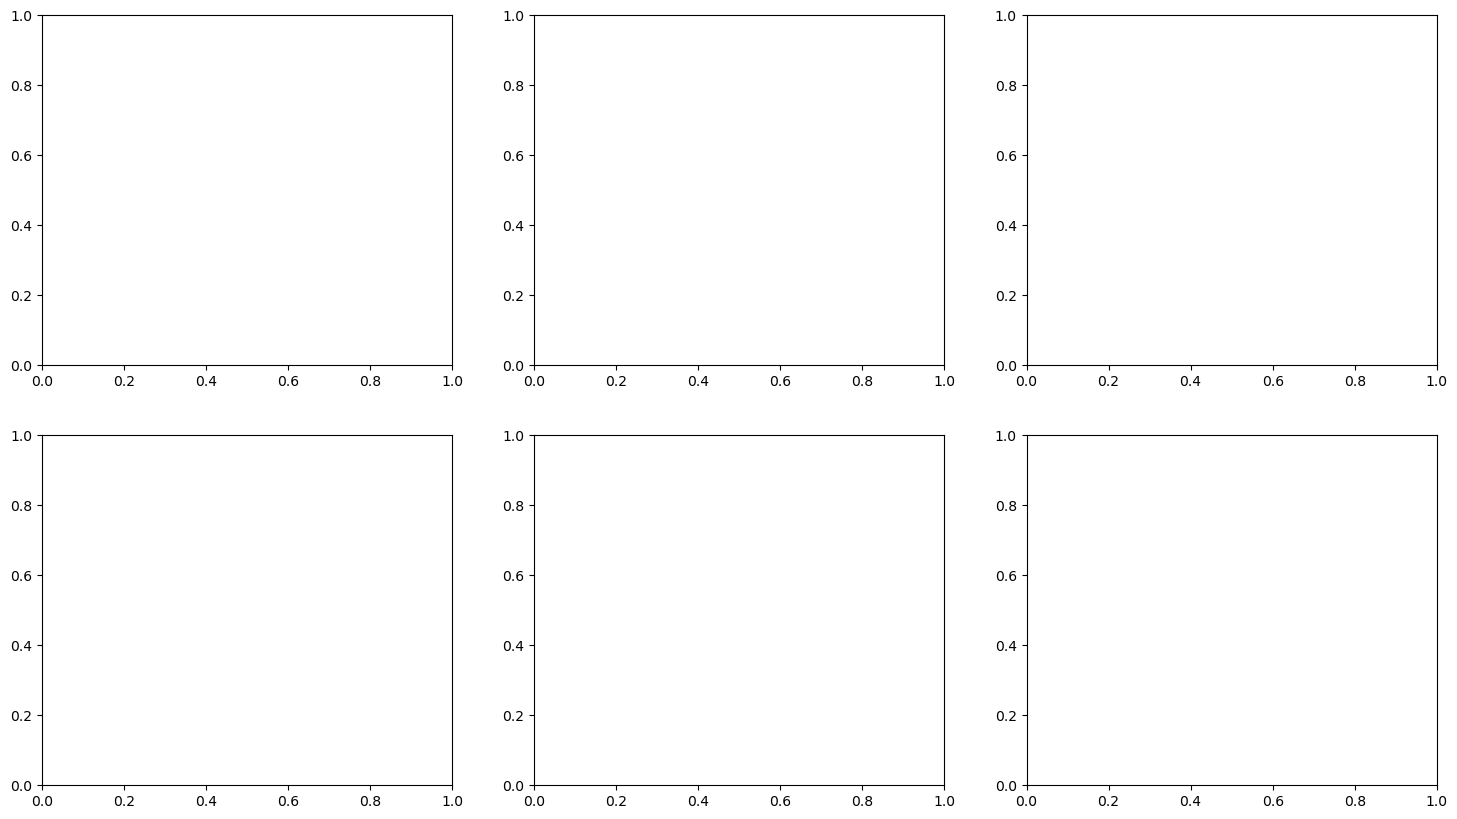

In [25]:
import json
from bsse_calculator.plotting_helpers import *

# energies = json.loads(open("Ne_tetramer_singlepoint.json", "r").read())
# energy_dfs = create_df(energies)
energy_dfs = run_all_calculations(energy_types_df)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (k, df) in zip(axes, energy_dfs.items()):
    formated_title = k.replace("_", " ")
    lines, labels = plot_dual_axis(
        df["Total Interaction Energy (BSSE free)"],
        df["Total BSSE"],
        df["type"],
        ax1=ax,
        title=f"Interaction Energy vs BSSE for {formated_title} (Ne)",
        x_label="Side Length (Å)",
        y1_label="Interaction Energy (kcal/mol)",
        y2_label="BSSE (kcal/mol)",
        label1="Interaction Energy",
        label2="BSSE",
    )
plt.suptitle("Total BSSE v Interaction Energy for Tetramer (H20)", fontsize=20)
plt.tight_layout()
ax.legend(
    lines, labels, prop={"size": 20}, loc="center left", bbox_to_anchor=(1.380, 0.5)
)
fig.delaxes(axes[-1])

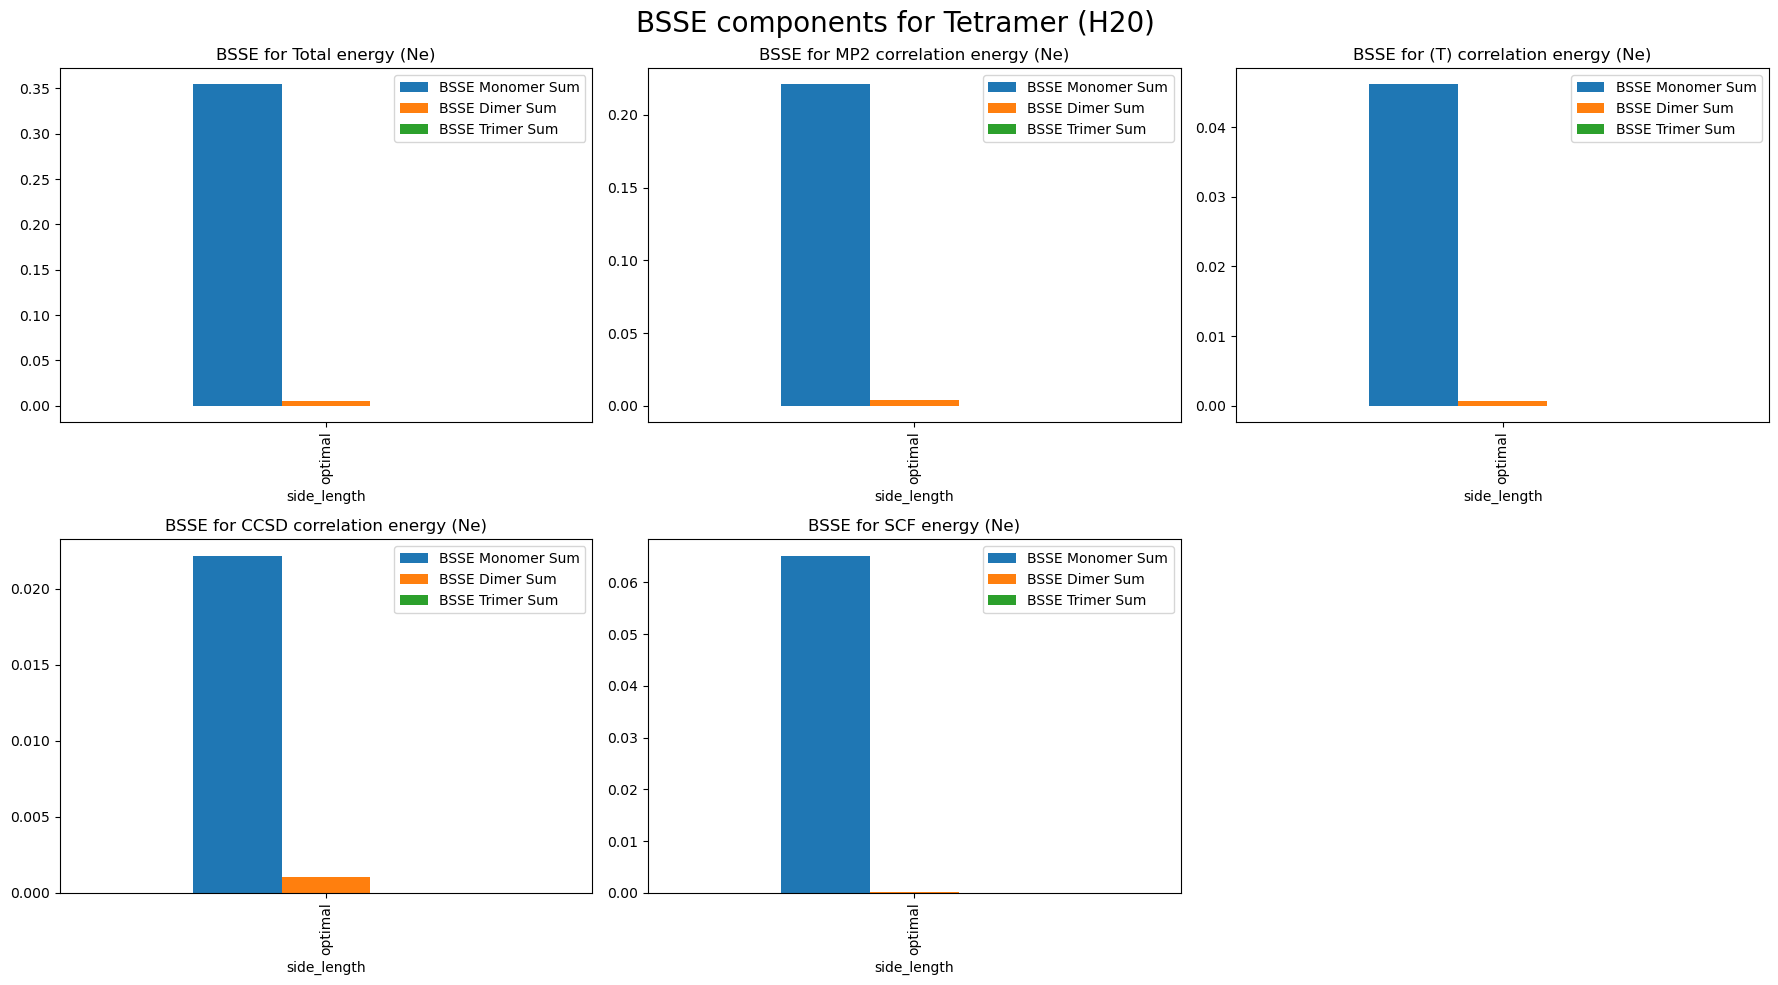

In [2]:
import json
from bsse_calculator.plotting_helpers import *

energies = json.loads(open("Ne_tetramer_singlepoint.json", "r").read())
energy_dfs = create_df(energies)
energy_dfs = {k: run_all_calculations(df) for k, df in energy_dfs.items()}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (k, df) in zip(axes, energy_dfs.items()):
    formated_title = k.replace("_", " ")
    tmp_df = df[
        ["side_length", "BSSE Monomer Sum", "BSSE Dimer Sum", "BSSE Trimer Sum"]
    ]
    tmp_df.plot(x="side_length", ax=ax, kind="bar")
    ax.set_title(f"BSSE for {formated_title} (Ne)")
plt.suptitle("BSSE components for Tetramer (H20)", fontsize=20)
plt.tight_layout()
# ax.legend(
#     lines, labels, prop={"size": 20}, loc="center left", bbox_to_anchor=(1.380, 0.5)
# )
fig.delaxes(axes[-1])

In [9]:
energy_dfs["SCF_energy"].columns.tolist()

['side_length',
 'E(B)_B',
 'E(A)_A',
 'E(C)_C',
 'E(D)_D',
 'E(AB)_A',
 'E(CD)_D',
 'E(BC)_C',
 'E(AB)_B',
 'E(AD)_D',
 'E(BC)_B',
 'E(CD)_C',
 'E(AD)_A',
 'E(BC)_BC',
 'E(CD)_CD',
 'E(AB)_AB',
 'E(AD)_AD',
 'E(AC)_A',
 'E(AC)_C',
 'E(BD)_D',
 'E(BD)_B',
 'E(BD)_BD',
 'E(AC)_AC',
 'E(ABD)_B',
 'E(ABD)_D',
 'E(ABC)_A',
 'E(BCD)_B',
 'E(ACD)_C',
 'E(BCD)_D',
 'E(ACD)_A',
 'E(ABC)_C',
 'E(ABC)_B',
 'E(ABD)_A',
 'E(ACD)_D',
 'E(BCD)_C',
 'E(BCD)_CD',
 'E(ABD)_AB',
 'E(ACD)_AD',
 'E(ABC)_BC',
 'E(ACD)_CD',
 'E(BCD)_BC',
 'E(ABC)_AB',
 'E(ABD)_AD',
 'E(BCD)_BD',
 'E(ACD)_AC',
 'E(ABC)_AC',
 'E(ABD)_BD',
 'E(ABC)_ABC',
 'E(ACD)_ACD',
 'E(ABD)_ABD',
 'E(BCD)_BCD',
 'E(ABCD)_B',
 'E(ABCD)_C',
 'E(ABCD)_D',
 'E(ABCD)_A',
 'E(ABCD)_BC',
 'E(ABCD)_CD',
 'E(ABCD)_AD',
 'E(ABCD)_AB',
 'E(ABCD)_AC',
 'E(ABCD)_BD',
 'E(ABCD)_ABD',
 'E(ABCD)_BCD',
 'E(ABCD)_ABC',
 'E(ABCD)_ACD',
 'E(ABCD)_ABCD',
 'Total Interaction Energy (w/ BSSE)',
 'Delta_E(AB)_AB',
 'Delta_E(AC)_AC',
 'Delta_E(AD)_AD',
 'Delta_E(B

In [12]:
tmp = energy_dfs["SCF_energy"]["E(ABCD)_ABCD"].copy()
for monomer in ["A", "B", "C", "D"]:
    tmp -= energy_dfs["SCF_energy"][f"E({monomer})_{monomer}"]

In [14]:
# Just SCF energy prediction no correction
def scf_prediction_total_energy_no_correction(energy_dfs):
    tmp = energy_dfs["SCF_energy"]["E(ABCD)_ABCD"].copy()
    for monomer in ["A", "B", "C", "D"]:
        tmp -= energy_dfs["SCF_energy"][f"E({monomer})_{monomer}"]
    return tmp

In [18]:
def energy_type_prediction(energy_dfs, energy_type):
    tmp = energy_dfs[energy_type]["E(ABCD)_ABCD"].copy()
    for monomer in ["A", "B", "C", "D"]:
        tmp -= energy_dfs[energy_type][f"E({monomer})_{monomer}"]
    return tmp

In [24]:
energy_dfs.keys()

dict_keys(['Total_energy', 'MP2_correlation_energy', '(T)_correlation_energy', 'CCSD_correlation_energy', 'SCF_energy'])

In [27]:
# so we have monomer level, dimer level and trimer level and then the prediction looks like
# def calculate_total_interaction_energy_with_correction(df):
#     working_total_interaction_energy_with_correction = df["E(ABCD)_ABCD"].copy()
# in monomer level
#     for monomer in ["A", "B", "C", "D"]:
#         working_total_interaction_energy_with_correction -= df[f"E(ABCD)_{monomer}"]
# in dimer level
#     for dimer in combinations(["A", "B", "C", "D"], 2):
#         working_total_interaction_energy_with_correction += (
#             -df[f"Delta_E(ABCD)_{dimer[0]}{dimer[1]}"]
#             + df[f"Delta_E({dimer[0]}{dimer[1]})_{dimer[0]}{dimer[1]}"]
#         )
# in trimer level
#     for trimer in combinations(["A", "B", "C", "D"], 3):
#         working_total_interaction_energy_with_correction += (
#             -df[f"Delta_E(ABCD)_{trimer[0]}{trimer[1]}{trimer[2]}"]
#             + df[
#                 f"Delta_E({trimer[0]}{trimer[1]}{trimer[2]})_{trimer[0]}{trimer[1]}{trimer[2]}"
#             ]
#         )
#     df["Total Interaction Energy (BSSE free)"] = (
#         working_total_interaction_energy_with_correction
#     )

energy_types_to_sum_dict = {
    "SCF_energy": ["SCF_energy"],
    "MP2_correlation_energy": ["SCF_energy", "MP2_correlation_energy"],
    "CCSD_correlation_energy": [
        "SCF_energy",
        "MP2_correlation_energy",
        "CCSD_correlation_energy",
    ],
    "(T)_correlation_energy": [
        "SCF_energy",
        "MP2_correlation_energy",
        "CCSD_correlation_energy",
        "(T)_correlation_energy",
    ],
}


def calculate_interaction_energy_estimate(energy_dfs, levels):
    for level in levels:
        if level not in [
            "MP2_correlation_energy",
            "(T)_correlation_energy",
            "CCSD_correlation_energy",
            "SCF_energy",
        ]:
            raise ValueError(f"level {level} not supported")
    working_estimate = df["Total_energy"]["E(ABCD)_ABCD"].copy()
    # subtract monomer
    for monomer in ["A", "B", "C", "D"]:
        energy_types_to_sum = energy_types_to_sum_dict[level[0]]
        for energy_type in energy_types_to_sum:
            working_estimate -= energy_dfs[energy_type][f"E({monomer})_{monomer}"]
    # subtract dimer
    for dimer in combinations(["A", "B", "C", "D"], 2):
        working_estimate += (
            -energy_dfs[level[1]][f"Delta_E(ABCD)_{dimer[0]}{dimer[1]}"]
            + energy_dfs[level[1]][
                f"Delta_E({dimer[0]}{dimer[1]})_{dimer[0]}{dimer[1]}"
            ]
        )
    # subtract trimer
    for trimer in combinations(["A", "B", "C", "D"], 3):
        working_estimate += (
            -energy_dfs[level[2]][f"Delta_E(ABCD)_{trimer[0]}{trimer[1]}{trimer[2]}"]
            + energy_dfs[level[2]][
                f"Delta_E({trimer[0]}{trimer[1]}{trimer[2]})_{trimer[0]}{trimer[1]}{trimer[2]}"
            ]
        )
    return working_estimate

In [28]:
calculate_interaction_energy_estimate(
    energy_dfs, ["SCF_energy", "SCF_energy", "SCF_energy"]
)

KeyError: 'Total_energy'

In [13]:
energy_dfs[
    [
        "Total Interaction Energy (BSSE free)",
        "Total BSSE",
        "type",
        "Total Interaction Energy (w/ BSSE)",
    ]
].head()

,Total Interaction Energy (BSSE free),Total BSSE,type,Total Interaction Energy (w/ BSSE)
0,-0.088668,-0.360144,Total_energy,-0.448812
1,-0.182792,-0.224931,MP2_correlation_energy,-0.407723
2,-0.019980,-0.046835,(T)_correlation_energy,-0.066814
3,-0.011876,-0.023156,CCSD_correlation_energy,-0.035032
4,0.125980,-0.065222,SCF_energy,0.060758


/var/folders/v1/k9l8hql13n1gcrjl_yh_gs5m0000gn/T/ipykernel_61357/3358647649.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df], axis=0)
/var/folders/v1/k9l8hql13n1gcrjl_yh_gs5m0000gn/T/ipykernel_61357/338203761.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df], axis=0)


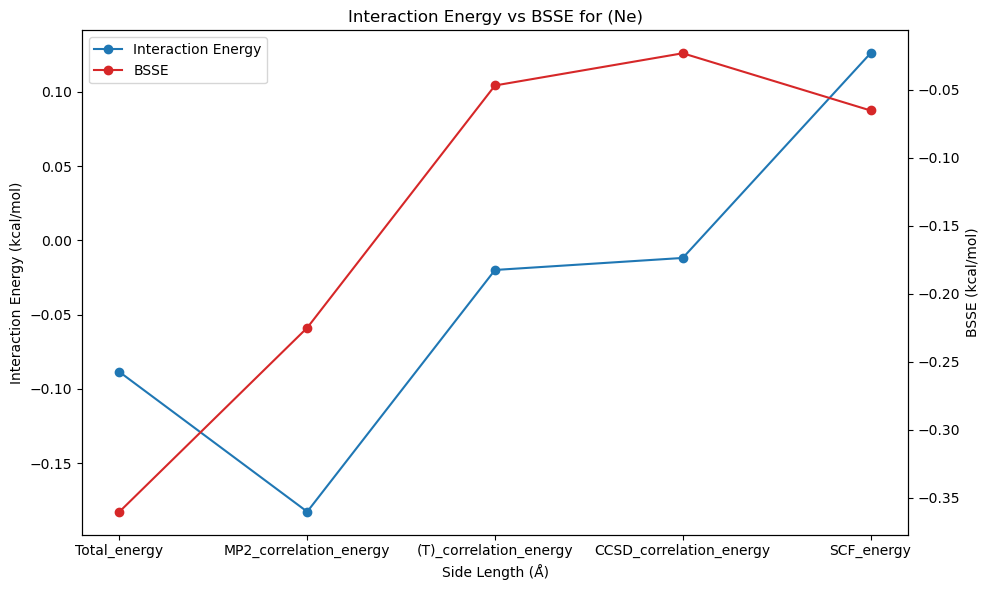

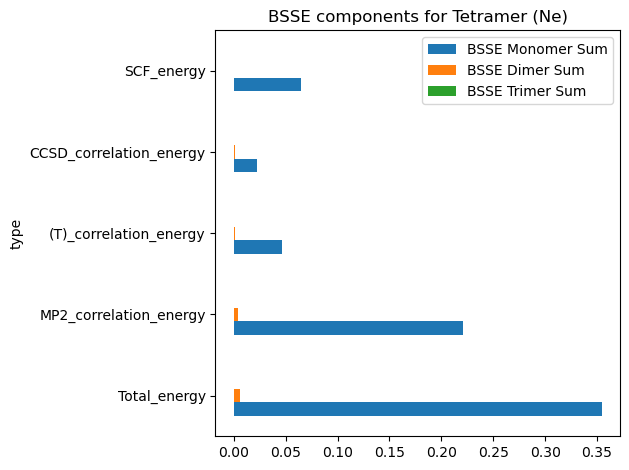

In [174]:
import json
from bsse_calculator.plotting_helpers import *

plot_interaction_v_bsse("Ne_tetramer_singlepoint.json")
plot_bsse_components("Ne_tetramer_singlepoint.json")

/var/folders/v1/k9l8hql13n1gcrjl_yh_gs5m0000gn/T/ipykernel_61357/338203761.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df], axis=0)


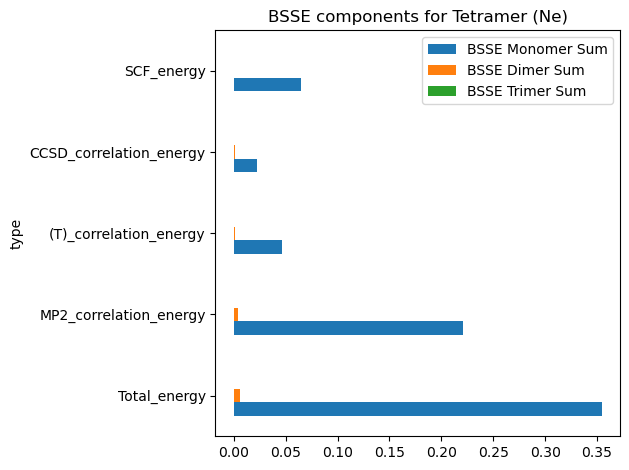

In [172]:
plot_bsse_components("Ne_tetramer_singlepoint.json")

In [10]:
energy_dfs = energy_dfs.drop(columns=["side_length"])

In [14]:
energy_dfs = energy_dfs.set_index("type")

In [ ]:
energy_dfs.loc[
    [
        "Total_energy",
        "SCF_energy",
        "MP2_correlation_energy",
        "CCSD_correlation_energy",
        "(T)_correlation_energy",
    ]
]

,E(A)_A,E(AB)_A,E(AC)_A,E(AD)_A,E(ABC)_A,E(ABD)_A,E(ACD)_A,E(ABCD)_A,E(B)_B,E(AB)_B,...,BSSE_Trimer(ABD),BSSE_Trimer(ACD),BSSE_Trimer(BCD),BSSE_Monomer(A),BSSE_Monomer(B),BSSE_Monomer(C),BSSE_Monomer(D),BSSE Dimer Sum,BSSE Trimer Sum,BSSE Monomer Sum
type,,,,,,,,,,,,,,,,,,,,,
Total_energy,-80767.572709,-80767.623794,-80767.623794,-80767.623794,-80767.675834,-80767.675834,-80767.675834,-80767.729018,-80767.572708,-80767.623792,...,-1.533481e-06,-4.410540e-06,-1.299108e-06,0.156309,0.066018,0.066019,0.066019,0.005789,-8.781179e-06,0.354364
SCF_energy,-80632.693021,-80632.702303,-80632.702303,-80632.702303,-80632.711685,-80632.711685,-80632.711685,-80632.721190,-80632.693021,-80632.702303,...,2.202287e-07,2.334418e-07,6.648770e-08,0.028169,0.012297,0.012297,0.012297,0.000160,7.322669e-07,0.065061
MP2_correlation_energy,-131.187075,-131.218370,-131.218370,-131.218370,-131.250402,-131.250402,-131.250402,-131.283303,-131.187075,-131.218370,...,-3.028879e-06,-3.026183e-06,-4.004390e-07,0.096228,0.041602,0.041602,0.041602,0.003907,-9.481760e-06,0.221034
CCSD_correlation_energy,-1.931624,-1.935347,-1.935347,-1.935347,-1.939050,-1.939050,-1.939050,-1.942740,-1.931623,-1.935345,...,1.625223e-06,-1.500624e-06,-6.559413e-07,0.011116,0.003673,0.003674,0.003674,0.001018,1.094398e-06,0.022137
(T)_correlation_energy,-1.760990,-1.767773,-1.767773,-1.767773,-1.774697,-1.774697,-1.774697,-1.781785,-1.760990,-1.767773,...,-3.495781e-07,-1.171673e-07,-3.093516e-07,0.020796,0.008446,0.008446,0.008446,0.000703,-1.125668e-06,0.046133


In [19]:
precision_levels = [
    "SCF_energy",
    "MP2_correlation_energy",
    "CCSD_correlation_energy",
    "(T)_correlation_energy",
]

# Initialize with zeros using the same column structure and proper index
up_to_level_df = pd.DataFrame(0.0, columns=energy_dfs.columns, index=precision_levels)

# Accumulate values up to each precision level
for i, level in enumerate(precision_levels):
    up_to_level_df.loc[level] = energy_dfs.loc[precision_levels[: i + 1]].sum()

up_to_level_df

,E(A)_A,E(AB)_A,E(AC)_A,E(AD)_A,E(ABC)_A,E(ABD)_A,E(ACD)_A,E(ABCD)_A,E(B)_B,E(AB)_B,...,BSSE_Trimer(ABD),BSSE_Trimer(ACD),BSSE_Trimer(BCD),BSSE_Monomer(A),BSSE_Monomer(B),BSSE_Monomer(C),BSSE_Monomer(D),BSSE Dimer Sum,BSSE Trimer Sum,BSSE Monomer Sum
SCF_energy,-80632.693021,-80632.702303,-80632.702303,-80632.702303,-80632.711685,-80632.711685,-80632.711685,-80632.721190,-80632.693021,-80632.702303,...,2.202287e-07,2.334418e-07,6.648770e-08,0.028169,0.012297,0.012297,0.012297,0.000160,7.322669e-07,0.065061
MP2_correlation_energy,-80763.880095,-80763.920674,-80763.920674,-80763.920674,-80763.962087,-80763.962087,-80763.962087,-80764.004493,-80763.880095,-80763.920674,...,-2.808650e-06,-2.792741e-06,-3.339513e-07,0.124398,0.053899,0.053899,0.053899,0.004067,-8.749493e-06,0.286095
CCSD_correlation_energy,-80765.811720,-80765.856020,-80765.856021,-80765.856020,-80765.901137,-80765.901137,-80765.901137,-80765.947233,-80765.811718,-80765.856019,...,-1.183427e-06,-4.293365e-06,-9.898927e-07,0.135513,0.057572,0.057573,0.057573,0.005085,-7.655095e-06,0.308231
(T)_correlation_energy,-80767.572709,-80767.623794,-80767.623794,-80767.623794,-80767.675834,-80767.675834,-80767.675834,-80767.729018,-80767.572708,-80767.623792,...,-1.533006e-06,-4.410532e-06,-1.299244e-06,0.156309,0.066018,0.066019,0.066019,0.005789,-8.780763e-06,0.354364


In [18]:
energy_dfs.loc["SCF_energy"]

E(A)_A             -8.063269e+04
E(AB)_A            -8.063270e+04
E(AC)_A            -8.063270e+04
E(AD)_A            -8.063270e+04
E(ABC)_A           -8.063271e+04
                        ...     
BSSE_Monomer(C)     1.229734e-02
BSSE_Monomer(D)     1.229729e-02
BSSE Dimer Sum      1.599202e-04
BSSE Trimer Sum     7.322669e-07
BSSE Monomer Sum    6.506117e-02
Name: SCF_energy, Length: 117, dtype: float64

In [48]:
geometry = """Ne     0.000000   -0.000000   -1.299484
Ne     1.732137    1.732137    0.433161
Ne     0.634006   -2.366143    0.433161
Ne    -2.366143    0.634006    0.433161"""

In [49]:
positions = np.array(
    [[float(x) for x in line.split()[1:]] for line in geometry.split("\n")]
)

In [50]:
coords = {"A": positions[0], "B": positions[1], "C": positions[2], "D": positions[3]}

In [51]:
coords

{'A': array([ 0.      , -0.      , -1.299484]),
 'B': array([1.732137, 1.732137, 0.433161]),
 'C': array([ 0.634006, -2.366143,  0.433161]),
 'D': array([-2.366143,  0.634006,  0.433161])}

In [ ]:
def get_basis_from_closest(closest_list, monomers, n):
    basis = set(monomers)
    while len(basis) < n:
        closest = closest_list.pop()
        basis.add(closest)
    return "".join(sorted(basis))

In [158]:
# estimate E(A)_ABCD


def get_n_closest(monomer, n, coords):
    """
    Returns E(basis)_monomer for the n monomers closest to monomer"""
    monomer_coords = coords[monomer]
    distances = np.linalg.norm(monomer_coords - np.array(list(coords.values())), axis=1)
    closest_n = np.argsort(distances)[:n]
    basis = "".join(sorted([list(coords.keys())[closest] for closest in closest_n]))
    return f"E({basis})_{monomer}"


def get_n_closest(monomers, n, coords):
    monomers_center_of_mass = np.mean([coords[monomer] for monomer in monomers], axis=0)
    distances = np.linalg.norm(
        monomers_center_of_mass - np.array(list(coords.values())), axis=1
    )
    closest_n = np.argsort(distances)
    basis = get_basis_from_closest(
        [list(coords.keys())[closest] for closest in closest_n], monomers, n
    )
    if len(monomers) == 1:
        return f"E({basis})_{monomers}"
    else:
        return f"Delta_E({basis})_{monomers}"


get_n_closest("A", 3, coords)

'E(ABD)_A'

In [159]:
def get_energy_type_calculation(df, monomers, energy_type, n, coords):
    if n == 0:
        return 0
    else:
        return df[get_n_closest(monomers, n, coords)][energy_type]

In [160]:
levels = {
    "SCF_energy": 4,
    "MP2_correlation_energy": 3,
    "CCSD_correlation_energy": 2,
    "(T)_correlation_energy": 0,
}


def estimate_monomers_energy(df, monomers, levels, coords):
    assert len(monomers) <= min(
        [value for value in levels.values() if value != 0]
    ), "Too many monomers"
    return sum(
        get_energy_type_calculation(df, monomers, energy_type, n, coords)
        for energy_type, n in levels.items()
    )


estimate_monomers_energy(energy_dfs, "AB", levels, coords)

np.float64(-0.013750100601708226)

In [ ]:
possible_levels = []
max_val = 4  # Set the max value of n1
for n1 in range(max_val, -1, -1):
    for n2 in range(n1, -1, -1):
        for n3 in range(n2, -1, -1):
            for n4 in range(n3, -1, -1):
                possible_levels.append((n1, n2, n3, n4))

In [131]:
possible_levels_dimer = []
max_val = 4  # Set the max value of n1
for n1 in range(max_val, -1, -1):
    for n2 in range(n1, -1, -1):
        for n3 in range(n2, -1, -1):
            for n4 in range(n3, -1, -1):
                if n1 != 1 and n2 != 1 and n3 != 1 and n4 != 1:
                    possible_levels_dimer.append((n1, n2, n3, n4))

In [102]:
from collections import defaultdict

results = {}
for levels in possible_levels:
    levels_dict = {
        "SCF_energy": levels[0],
        "MP2_correlation_energy": levels[1],
        "CCSD_correlation_energy": levels[2],
        "(T)_correlation_energy": levels[3],
    }
    avg_error = 0
    for monomer in ["A", "B", "C", "D"]:
        estimate = estimate_monomer_energy(energy_dfs, monomer, levels_dict, coords)
        avg_error += np.abs(energy_dfs[f"E(ABCD)_{monomer}"]["Total_energy"] - estimate)
    avg_error /= 4
    results[levels] = avg_error

In [135]:
results_sorted = sorted(results.items(), key=lambda x: x[1])
results_sorted = pd.DataFrame(results_sorted)
results_sorted = results_sorted.set_index(0)
results_sorted = results_sorted[:-5]
results_sorted = results_sorted.sort_index(ascending=False)
results_sorted.sort_values(by=1)[:40]

,1
0,
"(4, 4, 4, 4)",9.822543e-11
"(4, 4, 4, 3)",2.393563e-03
"(4, 4, 3, 3)",3.296118e-03
"(4, 4, 4, 2)",4.749839e-03
"(4, 4, 3, 2)",5.652394e-03
"(4, 4, 2, 2)",6.560103e-03
"(4, 4, 4, 1)",1.153322e-02
"(4, 4, 3, 1)",1.243577e-02
"(4, 4, 2, 1)",1.334348e-02


In [ ]:
from collections import defaultdict
from itertools import combinations

results_dimer = {}
for levels in possible_levels_dimer:
    levels_dict = {
        "SCF_energy": levels[0],
        "MP2_correlation_energy": levels[1],
        "CCSD_correlation_energy": levels[2],
        "(T)_correlation_energy": levels[3],
    }
    avg_error = 0
    for monomers in combinations(["A", "B", "C", "D"], 2):
        monomers = "".join(sorted(monomers))
        estimate = estimate_monomer_energy(energy_dfs, monomers, levels_dict, coords)
        avg_error += np.abs(
            energy_dfs[f"Delta_E(ABCD)_{monomers}"]["Total_energy"] - estimate
        )
    avg_error /= 6
    results_dimer[levels] = avg_error

results_dimer_sorted = sorted(results_dimer.items(), key=lambda x: x[1])
results_dimer_sorted = pd.DataFrame(results_dimer_sorted)
results_dimer_sorted = results_dimer_sorted.set_index(0)
results_dimer_sorted = results_dimer_sorted.sort_index(ascending=False)
results_dimer_sorted.sort_values(by=1)

,1
0,
"(4, 4, 4, 4)",1.160509e-10
"(4, 4, 4, 3)",6.867052e-05
"(4, 4, 4, 2)",1.171838e-04
"(4, 4, 3, 3)",1.704786e-04
"(4, 4, 3, 2)",2.189919e-04
"(4, 4, 2, 2)",2.868830e-04
"(4, 3, 3, 3)",5.482070e-04
"(3, 3, 3, 3)",5.653453e-04
"(4, 3, 3, 2)",5.967203e-04


In [134]:
results_dimer_sorted = sorted(results_dimer.items(), key=lambda x: x[1])
results_dimer_sorted = pd.DataFrame(results_dimer_sorted)
results_dimer_sorted = results_dimer_sorted.set_index(0)
results_dimer_sorted = results_dimer_sorted[:-5]
results_dimer_sorted = results_dimer_sorted.sort_index(ascending=False)
results_dimer_sorted.sort_values(by=1)[:40]

,1
0,
"(4, 4, 4, 4)",1.309672e-10
"(4, 4, 4, 3)",4.837981e-03
"(4, 4, 3, 3)",6.719267e-03
"(4, 4, 4, 2)",1.475248e-02
"(4, 4, 3, 2)",1.663377e-02
"(4, 4, 2, 2)",2.204352e-02
"(4, 3, 3, 3)",3.116186e-02
"(3, 3, 3, 3)",3.820338e-02
"(4, 3, 3, 2)",4.107636e-02


In [150]:
possible_levels_trimer = [
    levels
    for levels in possible_levels_dimer
    if not (1 in levels) and not (2 in levels)
]

In [155]:
[col for col in energy_dfs.columns if "Delta_E" in col]

['Delta_E(AB)_AB',
 'Delta_E(AC)_AC',
 'Delta_E(AD)_AD',
 'Delta_E(BC)_BC',
 'Delta_E(BD)_BD',
 'Delta_E(CD)_CD',
 'Delta_E(ABC)_AB',
 'Delta_E(ABC)_AC',
 'Delta_E(ABC)_BC',
 'Delta_E(ABD)_AB',
 'Delta_E(ABD)_AD',
 'Delta_E(ABD)_BD',
 'Delta_E(ACD)_AC',
 'Delta_E(ACD)_AD',
 'Delta_E(ACD)_CD',
 'Delta_E(BCD)_BC',
 'Delta_E(BCD)_BD',
 'Delta_E(BCD)_CD',
 'Delta_E(ABCD)_AB',
 'Delta_E(ABCD)_AC',
 'Delta_E(ABCD)_AD',
 'Delta_E(ABCD)_BC',
 'Delta_E(ABCD)_BD',
 'Delta_E(ABCD)_CD',
 'Delta_E(ABC)_ABC',
 'Delta_E(ABD)_ABD',
 'Delta_E(ACD)_ACD',
 'Delta_E(BCD)_BCD',
 'Delta_E(ABCD)_ABC',
 'Delta_E(ABCD)_ABD',
 'Delta_E(ABCD)_ACD',
 'Delta_E(ABCD)_BCD']

In [156]:
from collections import defaultdict
from itertools import combinations

results_trimer = {}
for levels in possible_levels_trimer:
    levels_dict = {
        "SCF_energy": levels[0],
        "MP2_correlation_energy": levels[1],
        "CCSD_correlation_energy": levels[2],
        "(T)_correlation_energy": levels[3],
    }
    avg_error = 0
    for monomers in combinations(["A", "B", "C", "D"], 3):
        monomers = "".join(sorted(monomers))
        estimate = estimate_monomer_energy(energy_dfs, monomers, levels_dict, coords)
        avg_error += np.abs(
            energy_dfs[f"Delta_E(ABCD)_{monomers}"]["Total_energy"] - estimate
        )
    avg_error /= 4
    results_trimer[levels] = avg_error

results_trimer_sorted = sorted(results_trimer.items(), key=lambda x: x[1])
results_trimer_sorted = pd.DataFrame(results_trimer_sorted)
results_trimer_sorted = results_trimer_sorted.set_index(0)
results_trimer_sorted = results_trimer_sorted[:-5]
results_trimer_sorted = results_trimer_sorted.sort_index(ascending=False)
results_trimer_sorted.sort_values(by=1)[:40]

,1
0,
"(0, 0, 0, 0)",0.000193
"(3, 0, 0, 0)",241898.047869
"(4, 0, 0, 0)",241898.065131
"(3, 3, 0, 0)",242291.817709
"(4, 3, 0, 0)",242291.834970
"(4, 4, 0, 0)",242291.885502
"(3, 3, 3, 0)",242297.630353
"(4, 3, 3, 0)",242297.647615
"(4, 4, 3, 0)",242297.698147


In [ ]:
def calculate_total_interaction_energy_with_correction(df):
    working_total_interaction_energy_with_correction = df["E(ABCD)_ABCD"].copy()
    for monomer in ["A", "B", "C", "D"]:
        working_total_interaction_energy_with_correction -= df[f"E(ABCD)_{monomer}"]
    for dimer in combinations(["A", "B", "C", "D"], 2):
        working_total_interaction_energy_with_correction += (
            -df[f"Delta_E(ABCD)_{dimer[0]}{dimer[1]}"]
            + df[f"Delta_E({dimer[0]}{dimer[1]})_{dimer[0]}{dimer[1]}"]
        )
    for trimer in combinations(["A", "B", "C", "D"], 3):
        working_total_interaction_energy_with_correction += (
            -df[f"Delta_E(ABCD)_{trimer[0]}{trimer[1]}{trimer[2]}"]
            + df[
                f"Delta_E({trimer[0]}{trimer[1]}{trimer[2]})_{trimer[0]}{trimer[1]}{trimer[2]}"
            ]
        )
    df["Total Interaction Energy (BSSE free)"] = (
        working_total_interaction_energy_with_correction
    )

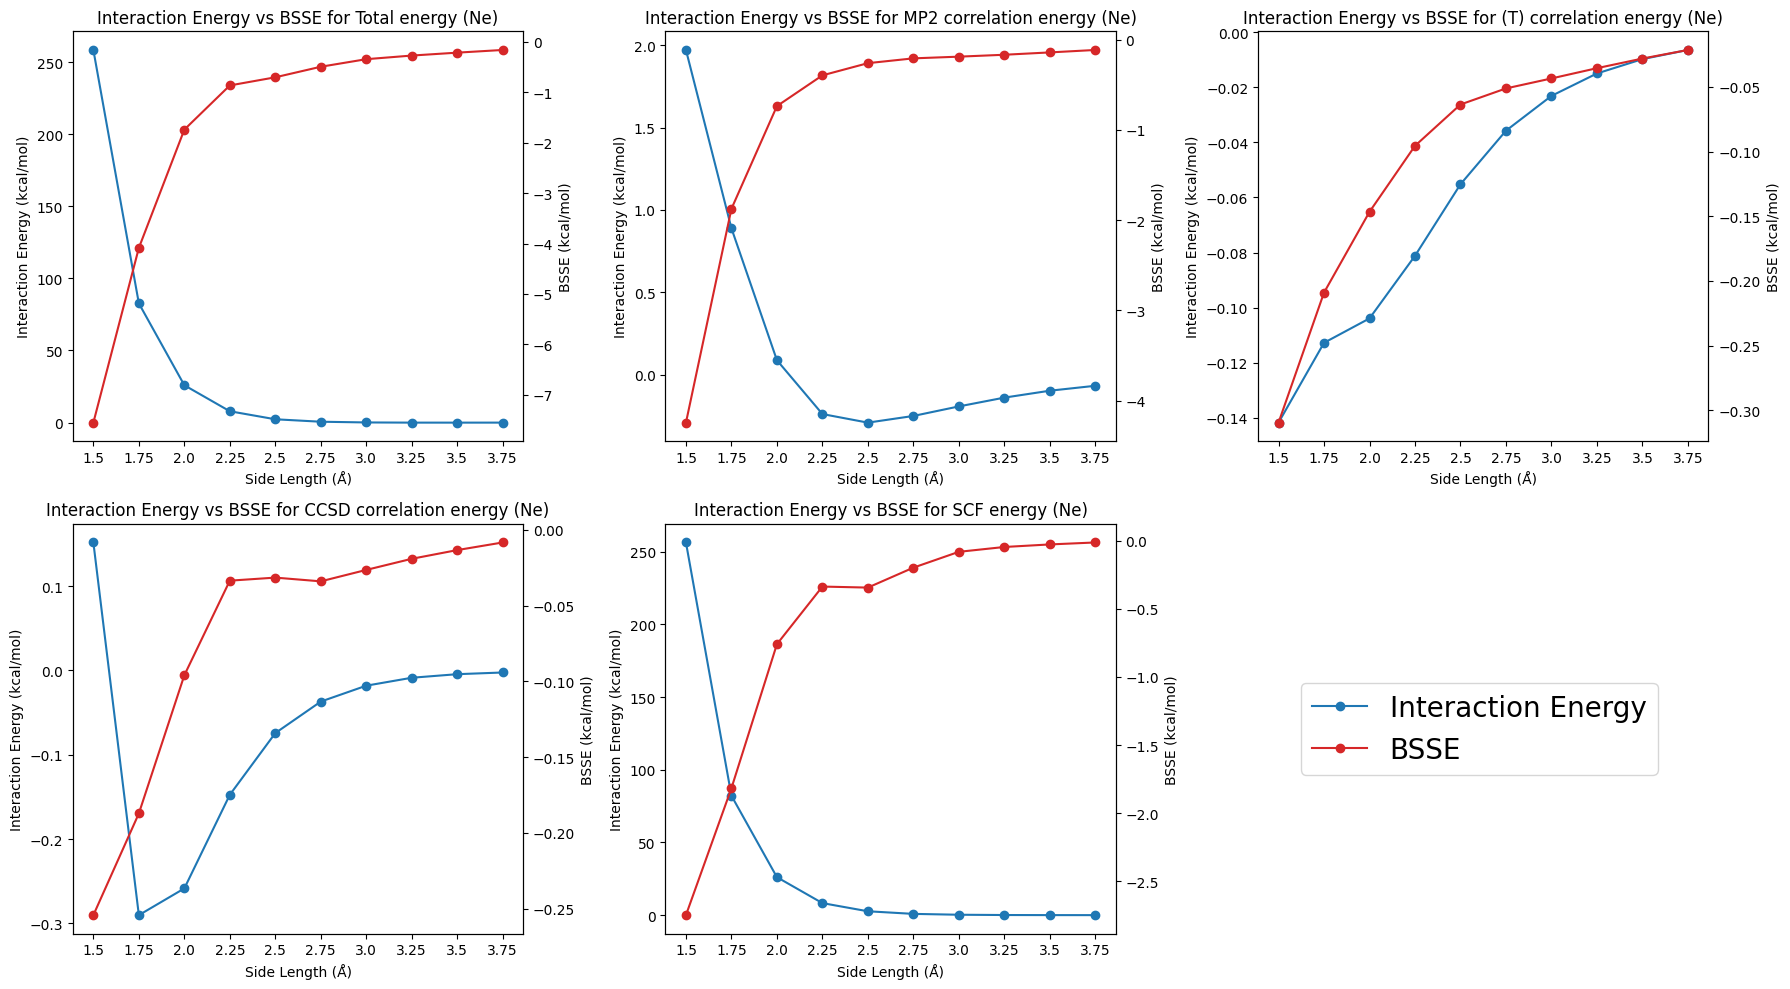

In [ ]:
import json
from bsse_calculator.plotting_helpers import *

energies = json.loads(open("Ne_trimer_energies.json", "r").read())
energy_dfs = create_df(energies)
energy_dfs = {
    k: create_BSSEs_and_interaction_energies(df) for k, df in energy_dfs.items()
}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (k, df) in zip(axes, energy_dfs.items()):
    formated_title = k.replace("_", " ")
    lines, labels = plot_dual_axis(
        df["Total Interaction Energy (BSSE free)"],
        df["Total BSSE"],
        df["side_length"],
        ax1=ax,
        title=f"Interaction Energy vs BSSE for {formated_title} (Ne)",
        x_label="Side Length (Å)",
        y1_label="Interaction Energy (kcal/mol)",
        y2_label="BSSE (kcal/mol)",
        label1="Interaction Energy",
        label2="BSSE",
    )
plt.tight_layout()
ax.legend(
    lines, labels, prop={"size": 20}, loc="center left", bbox_to_anchor=(1.380, 0.5)
)
fig.delaxes(axes[-1])

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:845: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df], axis=0)


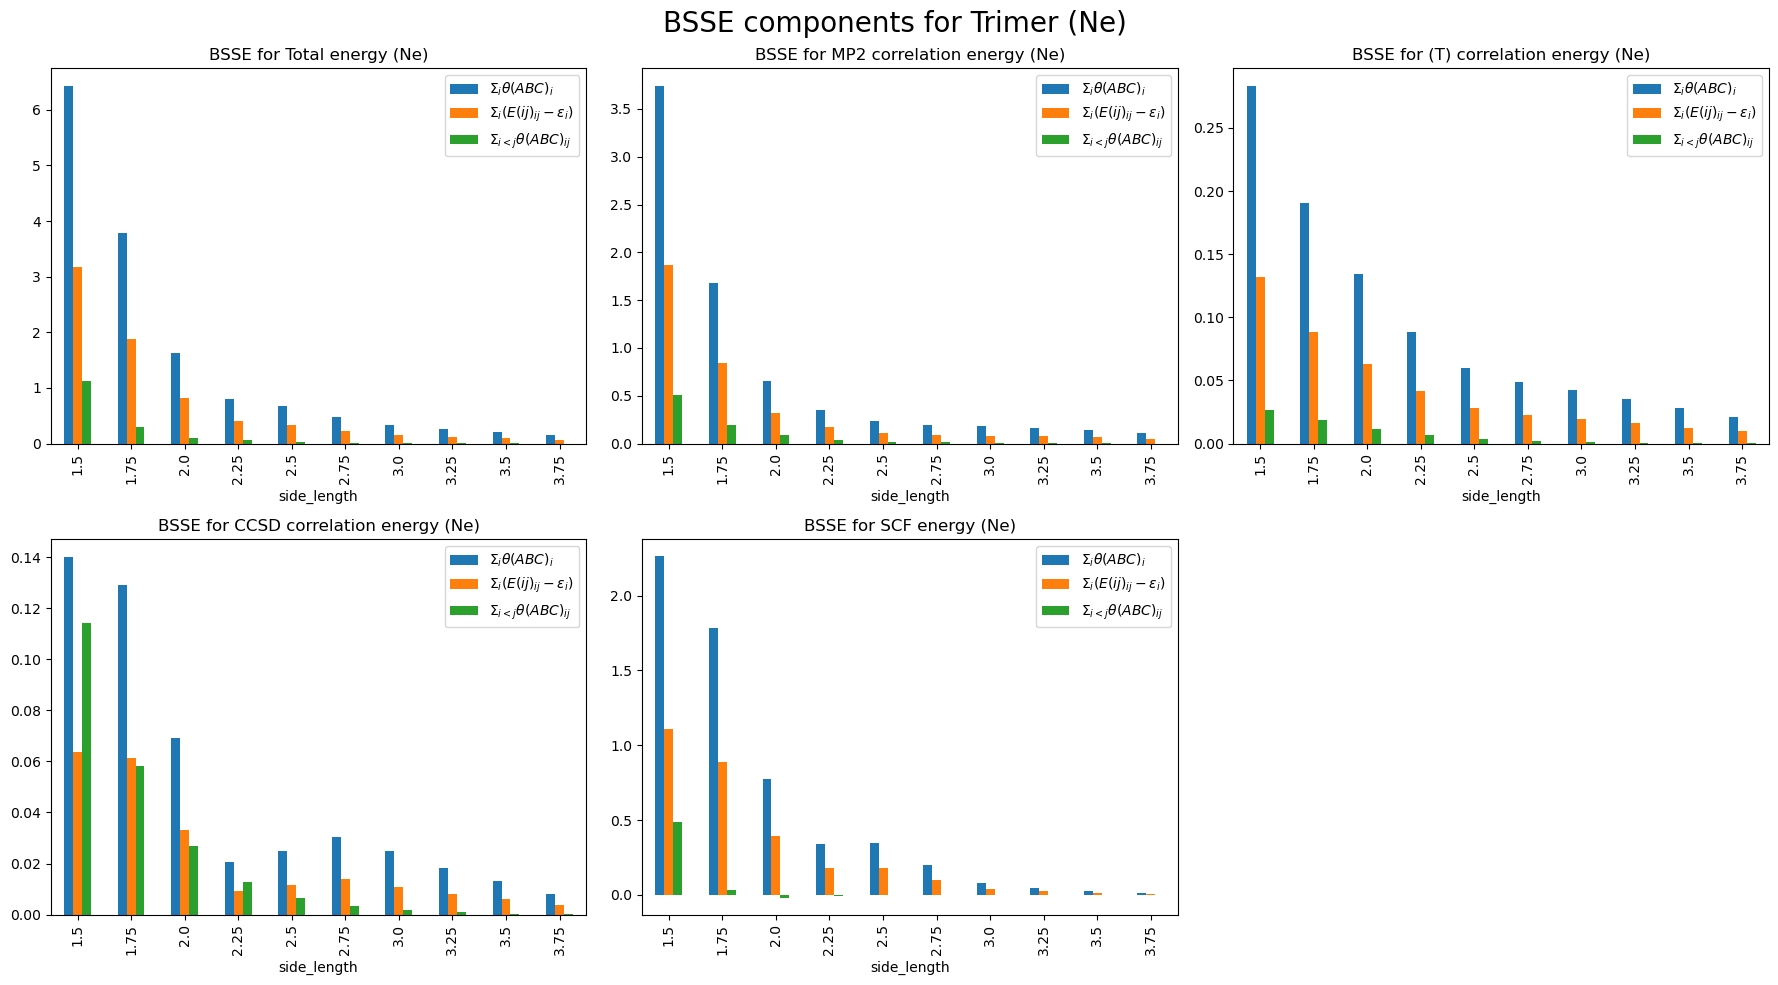

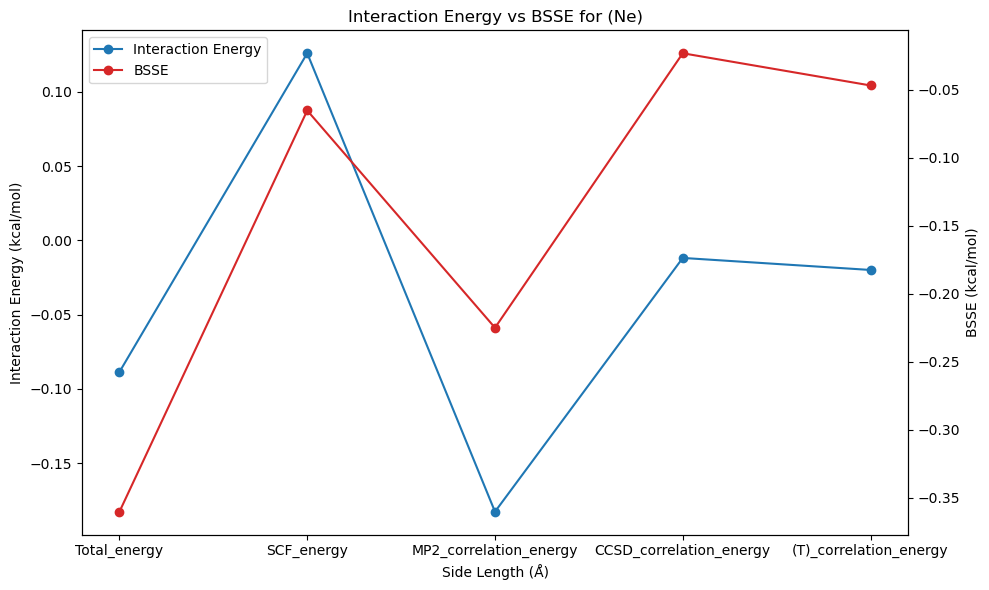

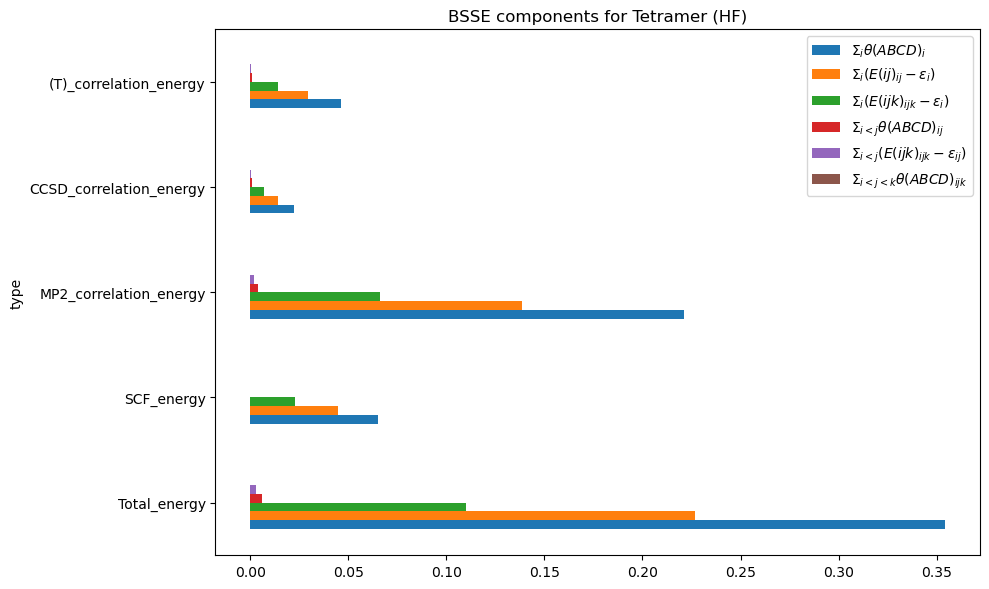

In [1]:
from bsse_calculator.plotting_helpers import *

plot_bsse_composition_trimer("Ne_trimer_energies.json", "Ne")
plot_bsse_composition_tetramer("Ne_tetramer_singlepoint.json", "Ne")

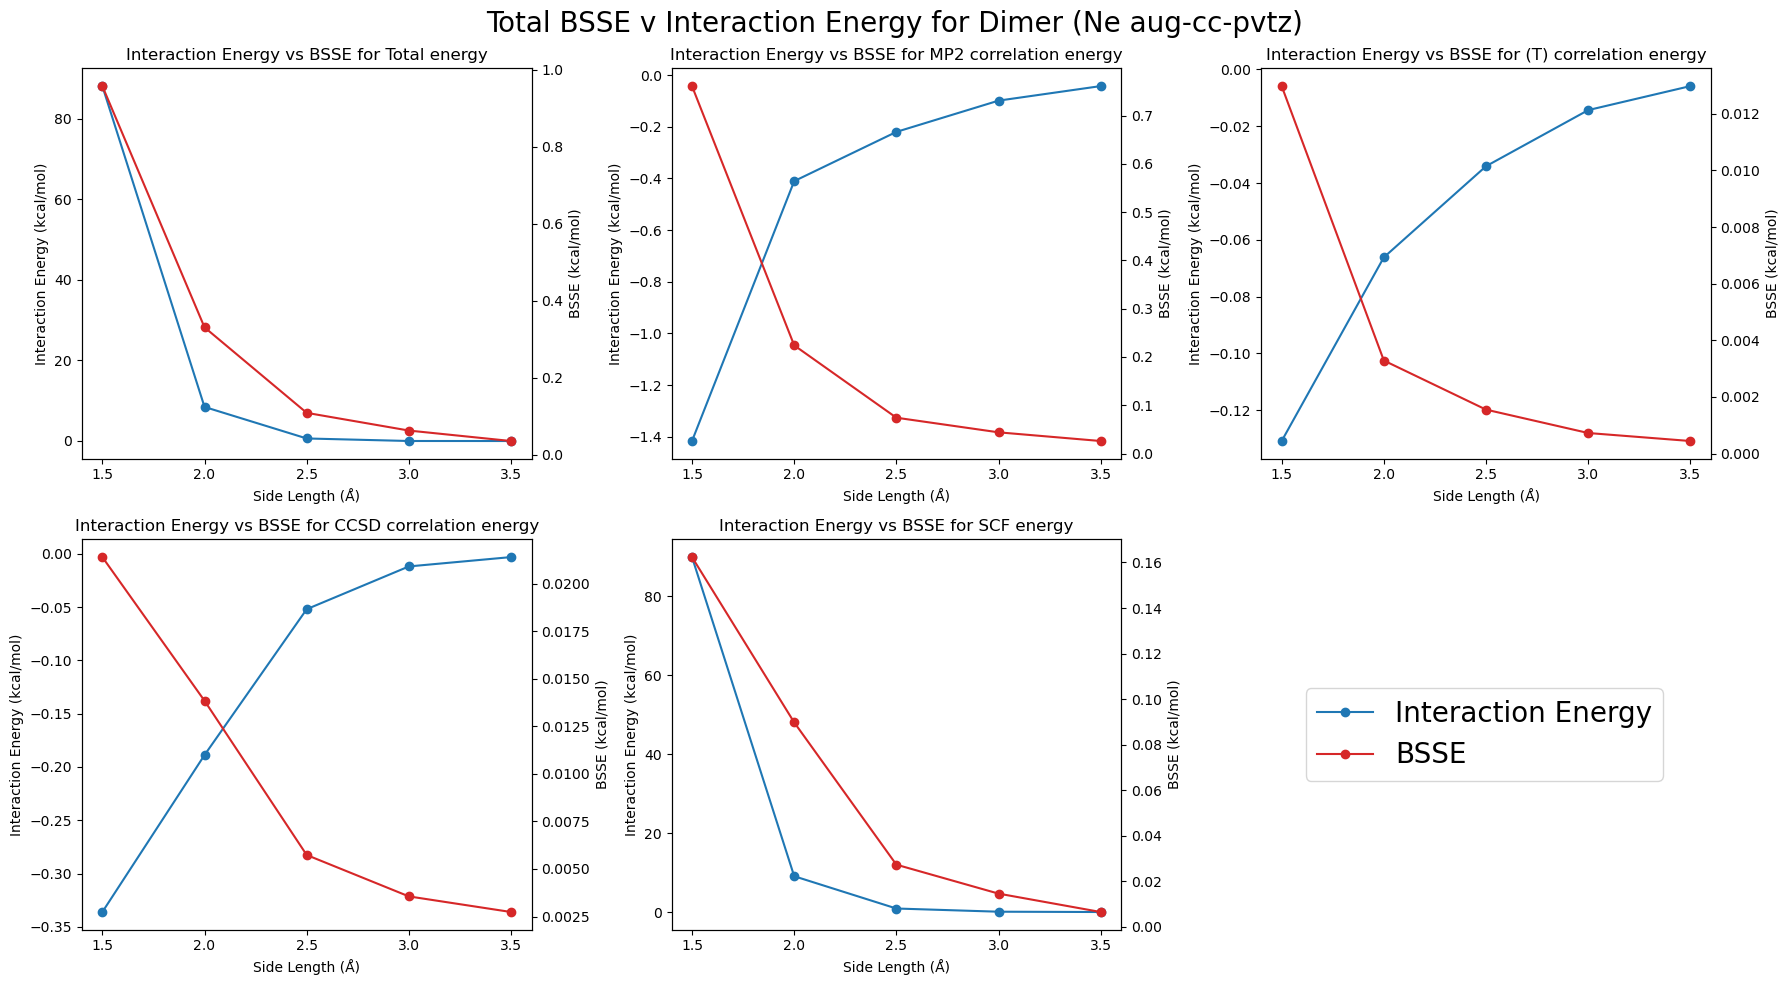

In [3]:
import json
from bsse_calculator.plotting_helpers import *

with open("Ne_dimer_energies_pvtz.json", "r") as f:
    data = json.load(f)
energy_types = [
    key.replace("_Delta_E_AB_AB", "")
    for key in next(iter(data.values())).keys()
    if key.endswith("_Delta_E_AB_AB")
]
regrouped_energies = defaultdict(list)
for side_length in data.keys():
    for energy_type in energy_types:
        row = {"side_length": side_length}
        for calculation in data[side_length].keys():
            if calculation.startswith(energy_type):
                row[calculation.replace(f"{energy_type}_", "")] = (
                    data[side_length][calculation] * 627.5096
                )
        regrouped_energies[energy_type].append(row)
energy_dfs = {
    energy_type: pd.DataFrame(regrouped_energies[energy_type])
    for energy_type in energy_types
}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (k, df) in zip(axes, energy_dfs.items()):
    formated_title = k.replace("_", " ")
    lines, labels = plot_dual_axis(
        df["Delta_E_AB_AB"],
        df["BSSE_A"],
        df["side_length"],
        ax1=ax,
        title=f"Interaction Energy vs BSSE for {formated_title}",
        x_label="Side Length (Å)",
        y1_label="Interaction Energy (kcal/mol)",
        y2_label="BSSE (kcal/mol)",
        label1="Interaction Energy",
        label2="BSSE",
    )
plt.suptitle("Total BSSE v Interaction Energy for Dimer (Ne aug-cc-pvtz)", fontsize=20)
plt.tight_layout()
ax.legend(
    lines, labels, prop={"size": 20}, loc="center left", bbox_to_anchor=(1.380, 0.5)
)
fig.delaxes(axes[-1])

In [3]:
bsse_data_nwchem_kcal

,Total_energy_Delta_E_AB_AB,Total_energy_BSSE_A,Total_energy_BSSE_B,MP2_correlation_energy_Delta_E_AB_AB,MP2_correlation_energy_BSSE_A,MP2_correlation_energy_BSSE_B,(T)_correlation_energy_Delta_E_AB_AB,(T)_correlation_energy_BSSE_A,(T)_correlation_energy_BSSE_B,CCSD_3correlation_energy_Delta_E_AB_AB,CCSD_3correlation_energy_BSSE_A,CCSD_3correlation_energy_BSSE_B,SCF_energy_Delta_E_AB_AB,SCF_energy_BSSE_A,SCF_energy_BSSE_B,x,y,z
0,"(0.12070293443522928,)","(0.0016113934782708839,)","(0.0016113789372411702,)","(0.001176588856947991,)","(0.0008926818617920051,)","(0.0008926818617920051,)","(-9.749837511700008e-05,)","(7.474404645900013e-05,)","(7.474191606899987e-05,)","(-0.0001700547910540029,)","(3.9793159140988354e-05,)","(3.978074851099245e-05,)","(0.11979389874500157,)","(0.0006041744109950287,)","(0.0006041744109950287,)",0.25,0.25,1.50
1,"(0.038844048469798054,)","(0.0009145926025837525,)","(0.0009145892712751902,)","(0.000462567117484991,)","(0.00038963348545001386,)","(0.00038963348545001386,)","(-7.638051839500013e-05,)","(5.1468304144000176e-05,)","(5.1467745805999776e-05,)","(-0.00023621150343802744,)","(3.433499617697122e-05,)","(3.4332223773969606e-05,)","(0.038694073375012294,)","(0.00043915581699138784,)","(0.000439155815996628,)",0.25,0.25,1.75
2,"(0.09158122520383927,)","(0.0014399945376908363,)","(0.0014399969626595066,)","(0.0009895248952359603,)","(0.0007500156333589969,)","(0.0007500156333589969,)","(-8.94719229260002e-05,)","(6.784029308200008e-05,)","(6.784012908199986e-05,)","(-0.0002139406700559232,)","(3.9164123401019824e-05,)","(3.916671221401713e-05,)","(0.0908951129019897,)","(0.0005829744879974896,)","(0.0005829744879974896,)",0.25,0.50,1.50
3,"(0.030491789810895398,)","(0.0007798524798943163,)","(0.0007798701282126785,)","(0.0003452619588210082,)","(0.0003183235513000149,)","(0.0003183235513000149,)","(-7.355556470199989e-05,)","(4.7856017739999774e-05,)","(4.785643302599981e-05,)","(-0.0002248037385700341,)","(3.1392715571981755e-05,)","(3.140994895298177e-05,)","(0.030444887155965716,)","(0.00038228019499797483,)","(0.00038228019499797483,)",0.25,0.50,1.75
4,"(0.05900256051458541,)","(0.0011651206262968117,)","(0.0011651282315199296,)","(0.0007005237532230479,)","(0.0005458606418900225,)","(0.0005458606418890233,)","(-8.162962489000015e-05,)","(5.862599681999989e-05,)","(5.8626378275999924e-05,)","(-0.0002413134525000582,)","(3.76433400149645e-05,)","(3.765056393997823e-05,)","(0.05862497983798676,)","(0.0005229906469992329,)","(0.0005229906469992329,)",0.25,0.75,1.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,"(0.0007642902005216001,)","(0.00016556184161231613,)","(0.00016559390883230662,)","(-0.00014791371507899553,)","(6.183008531202017e-05,)","(6.183008531202017e-05,)","(-2.610745192299993e-05,)","(1.5518654053000083e-05,)","(1.552122261500033e-05,)","(-3.4106340851020045e-05,)","(8.09258957895631e-06,)","(8.122088061973676e-06,)","(0.0009724177079704077,)","(8.01205119955739e-05,)","(8.012051299033374e-05,)",1.75,1.75,0.75
264,"(0.00047862814389532105,)","(0.000148410206435301,)","(0.000148413139186232,)","(-0.0001406688593429961,)","(5.8179593661999984e-05,)","(5.8179593661999984e-05,)","(-2.2453758952999808e-05,)","(1.4609336341000253e-05,)","(1.4608799260999988e-05,)","(-2.6869070097024217e-05,)","(8.692198126991624e-06,)","(8.69566794198251e-06,)","(0.0006686198320267067,)","(6.69290780024312e-05,)","(6.69290780024312e-05,)",1.75,1.75,1.00
265,"(0.00025197557579303975,)","(0.0001272606200757309,)","(0.00012725594913831628,)","(-0.00012929971914998895,)","(5.56995147160122e-05,)","(5.5699514715013e-05,)","(-1.862896502500015e-05,)","(1.3799492932000008e-05,)","(1.379759458700015e-05,)","(-1.9933699916985237e-05,)","(8.75776117298388e-06,)","(8.754988669978925e-06,)","(0.00041983795995292894,)","(4.9003850989493e-05,)","(4.9003850989493e-05,)",1.75,1.75,1.25
266,"(9.881891796226228e-05,)","(0.00010721165651261799,)","(0.00010721546948389005,)","(-0.0001

In [ ]:
BSSE_by_Ne_Ne_distance_nwchem

([<matplotlib.collections.PathCollection at 0x16b6bc1f0>,
 ['Interaction Energy', 'BSSE'])

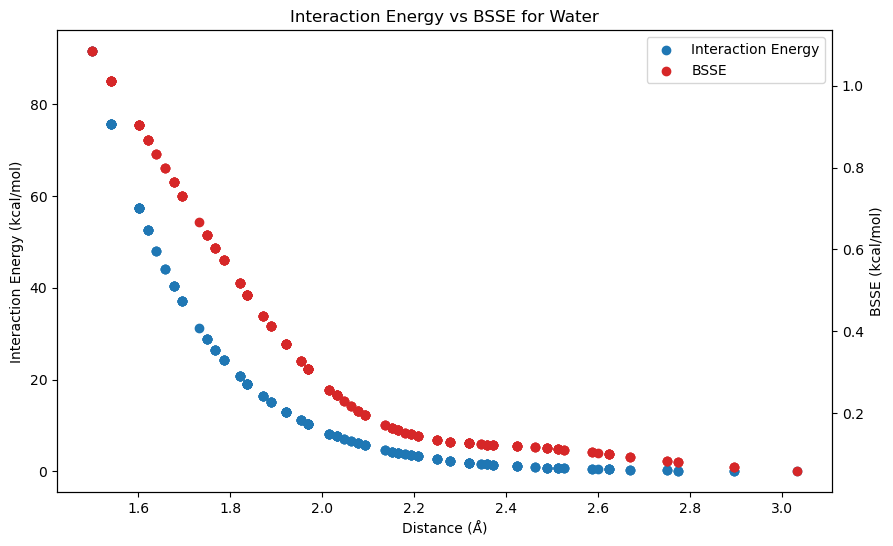

In [5]:
from bsse_calculator.plotting_helpers import *

bsse_data_nwchem_kcal = pd.read_csv("BSSE_by_Ne_Ne_distance_nwchem.csv")
bsse_data_nwchem_kcal["BSSE_A"] = (
    bsse_data_nwchem_kcal["Total_energy_BSSE_A"].apply(
        lambda x: float(x.strip("()").split(",")[0])
    )
    * 627.5096
)
bsse_data_nwchem_kcal["Delta_E_AB_AB"] = (
    bsse_data_nwchem_kcal["Total_energy_Delta_E_AB_AB"].apply(
        lambda x: float(x.strip("()").split(",")[0])
    )
    * 627.5096
)
import numpy as np

bsse_data_nwchem_kcal["distance"] = np.sqrt(
    bsse_data_nwchem_kcal["x"] ** 2
    + bsse_data_nwchem_kcal["y"] ** 2
    + bsse_data_nwchem_kcal["z"] ** 2
)
bsse_data_nwchem_kcal = bsse_data_nwchem_kcal.sort_values("distance")
plot_dual_axis(
    bsse_data_nwchem_kcal["Delta_E_AB_AB"],
    bsse_data_nwchem_kcal["BSSE_A"],
    bsse_data_nwchem_kcal["distance"],
    type="scatter",
    x_label="Distance (Å)",
    y1_label="Interaction Energy (kcal/mol)",
    y2_label="BSSE (kcal/mol)",
    title="Interaction Energy vs BSSE for Water",
    label1="Interaction Energy",
    label2="BSSE",
)